# SI Code 2a | Sampler-budget and proxy-definition sensitivity tests

Companion to `SI_code2_TEXAS_analysis.ipynb`. It answers two questions that the
main analysis notebook takes as settled:

**Part 1 — How many HMC iterations does the calibration actually need?**
The coretop layer is the expensive fit (N = 1513 sites, plus 2 × 1513 latent
variables in the EIV model), and it is re-run every time the training
compilation grows. We sweep warmup ∈ {100, 200, 300, 400, 500} × sampling ∈
{1, 1.5, 2, 2.5, 3} × warmup and show where R̂, ESS and the posterior means
themselves stop moving, so the production budget can be set from evidence
rather than from CmdStan's 1000/1000 default.

**Part 2 — Does the crenarchaeol ring assignment change the calibration?**
The Ring Index requires a ring count for crenarchaeol and its regioisomer,
which is a convention, not a measurement. We refit the entire two-stage
calibration under all three conventions in circulation:

| notebook label | column | crenarchaeol counted as | provenance |
|---|---|---|---|
| **SRI03** | `scaledRI_cren3` | 3 rings | this study (production calibration) |
| **SRI04** | `scaledRI` | 4 rings | RI₀₋₄ of Zhang et al. (2016) |
| **SRI05** | `scaledRI_cren5` | 5 rings | cyclopentane + cyclohexane counted |

Scaled RI is `RI / cren_rings`, so all three land on a comparable [0, 1] scale
and the comparison is about curve shape and skill, not units.

---

### Running this notebook

Everything is **cache-aware**: completed cases are read back from
`data/revision1/groupA/param_sensitivity/` and skipped. Delete that directory,
or set `FORCE_RERUN = True`, to resample.

| stage | iterations | wall time (8-core Linux box, 4 chains) |
|---|---|---|
| Part 1, univariate grid + references | 29,500 | ≈ 7 min |
| Part 1, EIV grid + references | 29,500 | ≈ 65 min |
| Part 2, SRI04 + SRI05 (SRI03 reuses the `SI_code2` posteriors) | — | ≈ 10 min |
| **total, cold cache** | | **≈ 1.4 h** |
| `QUICK = True` smoke run of both parts | | ≈ 12 min |

Measured 2026-08-12: 0.013 s/iteration for the univariate coretop model and
0.132 s/iteration for the EIV multivariate model, both at N = 1513 with 4
parallel chains.

> **Do not run a second Stan job while this notebook is sampling.** Every TEXAS
> process shares one compiled-binary directory (`~/.texas/stan_cache`) and this
> notebook already saturates 4 cores. Running two concurrently roughly triples
> the per-iteration cost and can kill the kernel outright, with no Python
> traceback — the progress bar simply turns red. Nothing is lost when that
> happens: `run_grid()` writes after every cell and skips what is already in
> `mcmc_budget_grid.csv`, so re-running the cell resumes where it stopped.

`QUICK = True` shrinks the grid and the iteration counts. It exercises every
code path and produces every figure, but the numbers are **not** publishable —
set it back to `False` for the real run.

# Environment

In [1]:
!python --version
import os
import warnings

# suppress warnings
warnings.filterwarnings('ignore')

Python 3.12.8


In [2]:
import json
import time
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

np.random.seed(42)   # reproducibility; Stan seeds are set explicitly below
xr.set_options(file_cache_maxsize=10)

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

import ultraplot as plot

# This notebook deliberately uses plain matplotlib (no ultraplot/arviz) so it
# runs in a bare `texas-env` without extra installs.

# The manuscript figures are set in TeX Gyre Heros (the Helvetica clone the AGU
# template uses), so the panel labels match the surrounding text. The font ships
# with TeX Live and with ultraplot; register it from wherever it is on this
# machine rather than assuming either is installed, and fall back to matplotlib's
# default silently if it is on neither.
def _register_texgyreheros():
    from matplotlib import font_manager as fm
    if any(f.name == 'TeX Gyre Heros' for f in fm.fontManager.ttflist):
        return True
    roots = [
        Path('/usr/share/texmf/fonts/opentype/public/tex-gyre'),
        Path('/usr/share/texlive/texmf-dist/fonts/opentype/public/tex-gyre'),
        Path('/usr/local/texlive/texmf-dist/fonts/opentype/public/tex-gyre'),
        Path(mpl.__file__).parents[1] / 'ultraplot' / 'fonts',
    ]
    for root in roots:
        if not root.is_dir():
            continue
        for f in sorted(root.glob('texgyreheros-*')):
            if f.suffix.lower() in ('.otf', '.ttf'):
                fm.fontManager.addfont(str(f))
    return any(f.name == 'TeX Gyre Heros' for f in fm.fontManager.ttflist)


HAVE_HEROS = _register_texgyreheros()
if not HAVE_HEROS:
    print('TeX Gyre Heros not found; falling back to the default sans-serif face')

mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['TeX Gyre Heros', 'Helvetica', 'Arial', 'DejaVu Sans'],
})

# Match the maths to the text: without a custom fontset the $\hat{R}$ and
# ESS$_{bulk}$ labels would render in DejaVu while everything around them is Heros.
if HAVE_HEROS:
    mpl.rcParams.update({
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'TeX Gyre Heros',
        'mathtext.it': 'TeX Gyre Heros:italic',
        'mathtext.bf': 'TeX Gyre Heros:bold',
        'mathtext.sf': 'TeX Gyre Heros',
        'mathtext.default': 'it',
    })

from tqdm.auto import tqdm

In [3]:
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler import StanSampler, get_posterior, auto_detect_predictors
from TEXAS.stan.io import load_posterior, save_posterior
from TEXAS.data import build_fwd_data
from TEXAS.diagnostics import summarize_sampler_diagnostics
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.models.multivariate import (
    generalized_logistic_fixed_upper_multivariate,
    inverse_generalized_logistic_fixed_upper_multivariate,
)

print("TEXAS", TEXAS.__version__, "->", TEXAS.__file__)

Set CMDSTAN -> /home/ronnie-rattan/.cmdstan/cmdstan-2.36.0
TEXAS 0.3.2 -> /home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/__init__.py


# Paths

In [4]:
IN_DOCKER = Path("/home/micromamba/app").exists()


def _find_repo_root(start=None):
    '''Walk up from the notebook until pyproject.toml appears.'''
    if IN_DOCKER:
        return Path("/home/micromamba/app")
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists() and (cand / "src" / "TEXAS").exists():
            return cand
    raise FileNotFoundError(
        f"Could not locate the TEXAS repo root above {p}. "
        "Set local_github_path by hand."
    )


local_github_path = _find_repo_root()

RESULTS_DIR = local_github_path / "data" / "revision1" / "groupA" / "param_sensitivity"
FIG_DIR     = local_github_path / "figures" / "manuscript" / "revision1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("repo    :", local_github_path)
print("results :", RESULTS_DIR)
print("figures :", FIG_DIR)


def savefig(fig, stem):
    '''Write both a PDF (for the SI) and a PNG (for quick viewing).'''
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight",
                    facecolor="white")
    print("saved ->", FIG_DIR / f"{stem}.[pdf|png]")

repo    : /home/ronnie-rattan/Documents/GitHub/TEXAS
results : /home/ronnie-rattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity
figures : /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/revision1


# Configuration

`QUICK` is the only switch you normally touch. Everything downstream — grid
size, iteration counts, which models are swept — derives from it.

In [5]:
QUICK       = False    # True -> fast smoke run; numbers are NOT publishable
FORCE_RERUN = False    # True -> ignore cached results and resample everything

CHAINS = 4             # held fixed: R-hat is only comparable at fixed chain count
SEED   = 42

# ── Part 1: the budget grid ────────────────────────────────────────────────
WARMUPS     = [100, 200, 300, 400, 500]
MULTIPLIERS = [1.0, 1.5, 2.0, 2.5, 3.0]     # iter_sampling = multiplier x warmup

# The reference ("gold standard") run every grid cell is compared against.
REF_WARMUP, REF_SAMPLING = 1000, 4000

# CmdStan's own default, shown on the figures as the incumbent production budget.
DEFAULT_WARMUP, DEFAULT_SAMPLING = 1000, 1000

# Models swept. The univariate coretop fit is cheap and thermal-only; the EIV
# multivariate fit is the production bottleneck and the one the recommendation
# is actually about.
# t0shift is swept as its own model rather than assumed to inherit the
# parent's budget. The two place the predictors differently -- the parent adds
# beta * G23 to the response, outside the logistic, while t0shift adds
# gamma * G23 to the inflection point, inside it. That makes gamma and t0
# near-degenerate whenever G23 has limited spread, and both gamma parameters
# are hard-bounded at zero with much wider priors than the betas -- which is
# why it cannot be assumed to inherit the parent's budget.
#
# It was expected to be the binding one. The sweep says otherwise: t0shift
# converges at warmup 300 where the parent needs 400, and does it in 79s
# against the parent's 141s. The reason for sweeping it separately stands --
# the budget does not transfer between models -- but the direction of the
# difference was guessed wrong, and the grid is what settled it.
GRID_MODELS = [
    ("univ",  "gen_logi_fixed_hier_crtp_univ_priorApprox"),
    ("eiv",   "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv"),
    ("bnd",   "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift"),
]

# The manuscript figures show the two arms the reported workflow uses: the
# univariate model, which supplies the thermal R^2, and t0shift, which is the
# calibration. The text discusses both, so both have to be visible -- prose
# about an arm the reader cannot see is prose they cannot check.
#
# All three arms are still swept, and dropping them from the *sweep* would cost
# the two claims the sweep exists to support: that the budget does not transfer
# between models (which needs a cross-model comparison to state at all), and
# that t0shift is not the binding arm despite the near-degeneracy of gamma and
# T0. Those comparisons stay in the recommendation printout, `recommended_budget.json`
# and `mcmc_budget_grid.csv` -- they are simply not plotted.
FIG_MODELS = [m for m in GRID_MODELS if m[0] in ("univ", "bnd")]

# ── Part 2: the proxy definitions ──────────────────────────────────────────
# label -> (column in the compilation, crenarchaeol ring count, plot colour)
PROXIES = {
    "SRI03": dict(column="scaledRI_cren3", cren_rings=3, color="#2e6f9e"),
    "SRI04": dict(column="scaledRI",       cren_rings=4, color="#c1832f"),
    "SRI05": dict(column="scaledRI_cren5", cren_rings=5, color="#8d5a9b"),
}
PRODUCTION_PROXY = "SRI03"

TEMPTYPE   = "SST"
NO3_CUTOFF = 1.0

# Analytical (measurement) SE of the *scaled* Ring Index fed to the EIV model.
#   "scaled_constant" -> 0.03 on every scaled proxy, i.e. the Schouten et al.
#                        (2013) reproducibility applied in scaled units.
#   "ri_constant"     -> 0.03 x 3 / cren_rings, i.e. holding the SE constant in
#                        raw RI units instead.
# The three conventions differ by <7% in scaled spread, so the choice is
# immaterial to the conclusion; it is exposed because it is a real assumption.
SD_PROXYOBS_MODE = "scaled_constant"
SD_PROXYOBS_BASE = 0.03

# ── Posterior names: ask TEXAS for them, do not spell them out ─────────────
#
# Hand-written legacy names like
#     gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3
# are the wrong thing to ask for in a way that does NOT raise. The 2026-08-12
# refit writes short case ids (tx.GHPU.sst.sri03.p0), but for SRI03 an old flat
# file still exists and resolve_posterior_path tries the exact legacy name
# FIRST -- so the legacy name silently resolves to the PRE-refit posterior
# while SRI04 and SRI05, which were never fitted twice, resolve to the current
# one. Part 2 was comparing a May SRI03 against August SRI04/SRI05.
#
# Building the name from attrs is the same call save_posterior makes, so it
# cannot drift from what is on disk. Same helper as SI_code02.
from TEXAS.utils.naming import case_from_attrs, resolve_posterior_path
from TEXAS.utils.paths import POSTERIOR_CACHE_DIR

_STEM = {
    "culmeso": "gen_logi_fixed_culmeso",
    "univ":    "gen_logi_fixed_hier_crtp_univ_priorApprox",
    "eiv":     "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv",
    "bnd":     "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift",
}


def fwd_name(model_key, proxy_col, *, temptype=None, gdgt23ratio=False,
             no3_cutoff=None):
    """Case id of a forward calibration, e.g. ``tx.GHEB.sst.sri03.G23-N1p0``."""
    attrs = {"stan_model_name": _STEM[model_key],
             "temptype": temptype or TEMPTYPE,
             "proxy_name": proxy_col,
             "use_gdgt23ratio": int(bool(gdgt23ratio)),
             "use_no3": int(no3_cutoff is not None)}
    if no3_cutoff is not None:
        attrs["no3_cutoff"] = float(no3_cutoff)
    return str(case_from_attrs(attrs))


def culmeso_name(proxy_col):
    """Stage-1 culture+mesocosm case id, e.g. ``tx.GCDU.cul.sri03.p0``."""
    return fwd_name("culmeso", proxy_col, temptype="cultureT")


def fwd_exists(name):
    """Is this calibration in the cache, under any layout?"""
    return resolve_posterior_path(str(name), POSTERIOR_CACHE_DIR) is not None


#: Readable model names for figure titles. The Stan file name
#: (gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift) is the wrong thing
#: to print on a manuscript figure: 54 characters of internal build detail that
#: names nothing a reader can look up. Titles carry the readable name plus the
#: case id, which IS the identifier the archived posterior is filed under.
MODEL_LABEL = {
    "univ": "univariate (prior-approximation)",
    "eiv":  "EIV multivariate, additive",
    "bnd":  "EIV multivariate, $T_0$-shift",
}

#: One hue family per model, so model identity reads the same way in every
#: figure: HUE = model, LIGHTNESS = warm-up length. Four unrelated colormaps on
#: one figure encoded nothing and competed for attention.
#: Blue and teal. These are adjacent hues and the families also carry LIGHTNESS
#: (warm-up), so they would converge at the pale end if the ramp ran to white.
#: Two things keep them apart: the teal is pushed well toward green rather than
#: sitting next to the blue, and `model_shades` starts its ramp at 0.38 rather
#: than at white, so even the shortest warm-up keeps a legible hue. Line style
#: carries the model as well, so hue is never the only channel.
MODEL_CMAP = {"univ": ["#ffffff", "#08519c"],    # blues
              "eiv":  ["#ffffff", "#8c6d31"],    # (not plotted)
              "bnd":  ["#ffffff", "#00695c"]}    # teals


def model_cmap(model_key, reverse=False):
    """White-to-colour colormap for one model."""
    from matplotlib.colors import LinearSegmentedColormap
    stops = MODEL_CMAP[model_key]
    if reverse:
        stops = stops[::-1]
    return LinearSegmentedColormap.from_list(f"tx_{model_key}", stops)


def model_shades(model_key, n):
    """`n` shades of one model's hue, light (short warm-up) to dark (long).

    The ramp starts at 0.38, not at 0. A ramp from white makes the palest
    warm-up of every model the same near-white, which is exactly where two
    adjacent hues stop being tellable apart.
    """
    cm = model_cmap(model_key)
    return [cm(0.38 + 0.62 * i / max(n - 1, 1)) for i in range(n)]


def model_title(model_key, proxy_col=None):
    """('EIV multivariate, $T_0$-shift', 'tx.GHEB.sst.sri03.G23-N1p0')"""
    proxy_col = proxy_col or PROXIES[PRODUCTION_PROXY]["column"]
    case = (fwd_name("univ", proxy_col) if model_key == "univ" else
            fwd_name(model_key, proxy_col, gdgt23ratio=True,
                     no3_cutoff=NO3_CUTOFF))
    return MODEL_LABEL[model_key], case


if QUICK:
    WARMUPS     = [100, 300]
    MULTIPLIERS = [1.0, 2.0]
    REF_WARMUP, REF_SAMPLING = 400, 800
    PART2_WARMUP, PART2_SAMPLING = 300, 300
else:
    PART2_WARMUP, PART2_SAMPLING = DEFAULT_WARMUP, DEFAULT_SAMPLING

GRID = [(w, int(round(w * m)), m) for w in WARMUPS for m in MULTIPLIERS]

print(f"QUICK={QUICK}  FORCE_RERUN={FORCE_RERUN}")
print(f"Part 1: {len(GRID)} budget cells x {len(GRID_MODELS)} models "
      f"= {len(GRID) * len(GRID_MODELS)} fits (+{len(GRID_MODELS)} reference runs)")
print(f"Part 2: {len(PROXIES)} proxies x 3 stages = {3 * len(PROXIES)} fits "
      f"at {PART2_WARMUP}/{PART2_SAMPLING}")

QUICK=False  FORCE_RERUN=False
Part 1: 25 budget cells x 3 models = 75 fits (+3 reference runs)
Part 2: 3 proxies x 3 stages = 9 fits at 1000/1000


# Training data

The same gridded, screened compilation the production calibration uses. Nothing
is re-screened here — both parts must see exactly the data the main notebook
sees, or the sensitivity test measures the wrong thing.

In [6]:
fpath = local_github_path / "data" / "spreadsheets"
fname = "ds_gridded_screened_global_compilation_finalized.csv"

gridded_combined_df = pd.read_csv(fpath / fname, low_memory=False)

PROXY_COLS = [v["column"] for v in PROXIES.values()]
missing = [c for c in PROXY_COLS if c not in gridded_combined_df.columns]
if missing:
    raise KeyError(f"proxy columns absent from the compilation: {missing}")

coretop_df = (gridded_combined_df[gridded_combined_df["datatype"] == "coretop"]
              .dropna(subset=["no3_sf2tc_avg", "SST"])
              .reset_index(drop=True))

print(f"compilation : {len(gridded_combined_df)} rows")
print(gridded_combined_df.groupby("datatype")[PROXY_COLS + ["SST"]].count())
print(f"\ncoretop (NO3 + SST complete): {len(coretop_df)}")

compilation : 1576 rows
          scaledRI_cren3  scaledRI  scaledRI_cren5   SST
datatype                                                
coretop             1513      1513            1513  1513
culture               55        55              55    55
mesocosm               8         8               8     8

coretop (NO3 + SST complete): 1513


In [7]:
# Sanity check on the ring-count convention: scaled RI x cren_rings must
# reproduce the unscaled Ring Index column it was derived from.
_ri_pairs = {"scaledRI_cren3": "ringIndex_cren3",
             "scaledRI":       "ringIndex",
             "scaledRI_cren5": "ringIndex_cren5"}
for label, cfg in PROXIES.items():
    col = cfg["column"]
    ri  = _ri_pairs[col]
    err = (gridded_combined_df[col] * cfg["cren_rings"]
           - gridded_combined_df[ri]).abs().max()
    print(f"{label:6s} {col:16s} x {cfg['cren_rings']}  vs {ri:16s} "
          f"max|diff| = {err:.2e}")

SRI03  scaledRI_cren3   x 3  vs ringIndex_cren3  max|diff| = 8.88e-16
SRI04  scaledRI         x 4  vs ringIndex        max|diff| = 8.88e-16
SRI05  scaledRI_cren5   x 5  vs ringIndex_cren5  max|diff| = 1.33e-15


---
# Part 1 | How many HMC iterations does the coretop fit need?

### What is measured, and why the low-level sampler is used here

Three models are swept: the univariate coretop fit, the parent additive-EIV
multivariate fit, and the T0-shift variant. The budget is **not** assumed to
transfer between them — R̂ at a fixed budget already differs measurably between
the univariate and parent fits — so each gets its own grid and its own
recommendation.

T0-shift was expected to be the hardest of the three, because gamma enters
*inside* the logistic (on the inflection point) rather than outside it, making
gamma and T₀ near-degenerate when G2/3 has limited spread. The sweep does not
support that: T0-shift converges at warmup 300 where the parent needs 400.
The expectation is recorded here rather than quietly deleted, because it is
the reason the third grid was run at all.

All three arms are **swept**; only **T0-shift is plotted**. The figures below
report the calibration the revision actually uses, so a reader takes away one
budget rather than three. The cross-model comparison that justifies the two
claims above is not lost — it stays in the recommendation printout, in
`recommended_budget.json`, and in `mcmc_budget_grid.csv`, which carry all three.

Part 1 calls `StanCompiler` / `CmdStanModel.sample` directly rather than
`get_posterior()`. The reason is diagnostic resolution: `get_posterior()`
attaches only the *aggregate* diagnostics (max R̂, min ESS) to the returned
dataset, and this test needs CmdStan's **per-parameter** `R_hat` / `ESS_bulk` /
`ESS_tail` table to show *which* parameter is the last to converge. The data
dict is passed through `auto_detect_predictors()` first, exactly as
`get_posterior()` does, so the model sees identical inputs.

Four families of metric are recorded per budget cell:

| family | metric | why |
|---|---|---|
| **convergence** | max R̂ over all parameters, count of R̂ > 1.01 | the headline question |
| **efficiency** | min/median ESS_bulk, ESS_tail, **ESS_bulk per second** | a cheap run that mixes badly is not cheap |
| **validity** | % divergent transitions, % at max treedepth, min E-BFMI | R̂ can look fine while the geometry is broken |
| **accuracy** | ‖posterior mean − reference mean‖ / reference SD | R̂ is a necessary, not sufficient, condition |

The last one is the check that matters for a calibration: a budget is only
adequate if the posterior it produces is indistinguishable from a long
reference run, not merely internally consistent.

In [8]:
# Both naming conventions are listed because the accuracy check below only
# covers parameters it can find. Omitting the gamma_* pair would silently
# exclude t0shift's two hardest-to-identify parameters from exactly the test
# that exists to catch them. Missing names are skipped per model, so listing
# both is safe.
CORE_PARAMS = ["t0_crtp", "k_crtp", "b_crtp", "v_crtp", "sigma_proxyObs_crtp",
               "beta_G23_crtp", "beta_NO3_crtp",      # parent (additive EIV)
               "gamma_G23_crtp", "gamma_NO3_crtp"]    # t0shift

_compiler = StanCompiler()


def build_part1_data(model_key, proxy_col=None):
    '''Stan data dict for the Part 1 grid, for one of the two swept models.'''
    proxy_col = proxy_col or PROXIES[PRODUCTION_PROXY]["column"]
    culmeso_post = load_posterior(culmeso_name(proxy_col))

    if model_key == "univ":
        reg = coretop_df[["SST", proxy_col]].dropna()
        return build_fwd_data(
            t_crtp=reg["SST"].values,
            proxy_crtp=reg[proxy_col].values,
            culmeso_posterior=culmeso_post,
        ), len(reg)

    # The two EIV models declare byte-identical Stan data blocks (16 keys), so
    # one builder serves both.
    if model_key in ("eiv", "bnd"):
        reg = coretop_df[["SST", proxy_col, "gdgt23ratio", "gdgt23ratio_se",
                          "no3_sf2tc_avg", "thermoNO3_se"]].dropna()
        thermal_post = load_posterior(fwd_name("univ", proxy_col))
        R2_thermal = float(thermal_post["R2_full"].mean())
        return build_fwd_data(
            t_crtp              = reg["SST"].values,
            proxy_crtp          = reg[proxy_col].values,
            gdgt23ratio_crtp    = reg["gdgt23ratio"].values,
            sd_gdgt23ratio_crtp = reg["gdgt23ratio_se"].values,
            no3_crtp            = reg["no3_sf2tc_avg"].values,
            sd_no3_crtp         = reg["thermoNO3_se"].values,
            R2_thermal          = R2_thermal,
            culmeso_posterior   = culmeso_post,
            no3_cutoff          = NO3_CUTOFF,
        ), len(reg)

    raise ValueError(
        f"unknown model key {model_key!r}; expected one of "
        f"{sorted({k for k, _ in GRID_MODELS})}"
    )

In [9]:
def run_budget_case(model_key, stan_file, data, iter_warmup, iter_sampling,
                    seed=SEED, chains=CHAINS):
    '''
    Sample once at a given budget and return (metrics dict, per-parameter table).

    Wall time is measured around `model.sample` only — compilation is excluded,
    since it happens once per session and is not part of the budget question.
    '''
    model = _compiler.get_model(stan_file)          # cached after the first call

    t_start = time.time()
    fit = model.sample(
        data=data,
        chains=chains,
        parallel_chains=chains,
        iter_warmup=iter_warmup,
        iter_sampling=iter_sampling,
        seed=seed,
        show_progress=False,
        show_console=False,
    )
    wall = time.time() - t_start

    summary = fit.summary()                          # CmdStan's own R_hat / ESS
    diag    = summarize_sampler_diagnostics(fit)

    # lp__ is not a model parameter; keep it out of the "did the parameters
    # converge" statistics but report it separately, since it is the most
    # sensitive single indicator of a badly adapted warmup.
    params = summary.drop(index=[i for i in summary.index if i == "lp__"],
                          errors="ignore")

    row = {
        "model": model_key,
        "stan_file": stan_file,
        "iter_warmup": iter_warmup,
        "iter_sampling": iter_sampling,
        "multiplier": iter_sampling / iter_warmup,
        "chains": chains,
        "total_draws": chains * iter_sampling,
        "total_iters": chains * (iter_warmup + iter_sampling),
        "wall_sec": wall,
        "max_rhat": float(params["R_hat"].max()),
        "n_rhat_gt_101": int((params["R_hat"] > 1.01).sum()),
        "n_rhat_gt_105": int((params["R_hat"] > 1.05).sum()),
        "worst_rhat_param": str(params["R_hat"].idxmax()),
        "lp_rhat": float(summary.loc["lp__", "R_hat"]) if "lp__" in summary.index else np.nan,
        "min_ess_bulk": float(params["ESS_bulk"].min()),
        "median_ess_bulk": float(params["ESS_bulk"].median()),
        "min_ess_tail": float(params["ESS_tail"].min()) if "ESS_tail" in params else np.nan,
        "pct_divergent": diag["stan_diag_pct_divergent"],
        "pct_max_treedepth": diag["stan_diag_pct_max_treedepth"],
        "min_ebfmi": diag["stan_diag_min_ebfmi"],
    }
    row["ess_bulk_per_sec"] = row["min_ess_bulk"] / wall
    row["sec_per_1000_draws"] = 1000 * wall / row["total_draws"]

    # Per-parameter draws for the core scalars -> mean/sd used by the accuracy
    # comparison against the reference run.
    ds = fit.draws_xr()
    par_rows = []
    for p in CORE_PARAMS:
        if p not in ds:
            continue
        v = np.asarray(ds[p].values, dtype=float).ravel()
        par_rows.append({
            "model": model_key, "iter_warmup": iter_warmup,
            "iter_sampling": iter_sampling, "param": p,
            "mean": float(v.mean()), "sd": float(v.std(ddof=1)),
            "q025": float(np.percentile(v, 2.5)),
            "q500": float(np.percentile(v, 50)),
            "q975": float(np.percentile(v, 97.5)),
            "rhat": float(summary.loc[p, "R_hat"]) if p in summary.index else np.nan,
            "ess_bulk": float(summary.loc[p, "ESS_bulk"]) if p in summary.index else np.nan,
        })
    return row, pd.DataFrame(par_rows)

In [10]:
GRID_CSV  = RESULTS_DIR / "mcmc_budget_grid.csv"
PARAM_CSV = RESULTS_DIR / "mcmc_budget_params.csv"

_KEY = ["model", "iter_warmup", "iter_sampling"]


def _load_cached(path):
    if path.exists() and not FORCE_RERUN:
        return pd.read_csv(path)
    return pd.DataFrame()


def _already_done(df, model_key, w, s):
    if df.empty:
        return False
    return bool(((df["model"] == model_key) & (df["iter_warmup"] == w)
                 & (df["iter_sampling"] == s)).any())


def run_grid():
    '''Run every (model, budget) cell not already cached; append as we go.'''
    grid_df  = _load_cached(GRID_CSV)
    param_df = _load_cached(PARAM_CSV)

    # Reference + incumbent-default budgets are run alongside the grid so they
    # appear in the same table with the same metrics.
    extra = [(REF_WARMUP, REF_SAMPLING), (DEFAULT_WARMUP, DEFAULT_SAMPLING)]
    todo = []
    for model_key, stan_file in GRID_MODELS:
        budgets = [(w, s) for w, s, _ in GRID] + extra
        seen = set()
        for w, s in budgets:
            if (w, s) in seen:
                continue
            seen.add((w, s))
            if not _already_done(grid_df, model_key, w, s):
                todo.append((model_key, stan_file, w, s))

    if not todo:
        print("all grid cells cached — nothing to run")
        return grid_df, param_df

    print(f"{len(todo)} cell(s) to sample")
    data_cache = {}
    for model_key, stan_file, w, s in tqdm(todo, desc="budget grid"):
        if model_key not in data_cache:
            data_cache[model_key] = build_part1_data(model_key)
        data, n_obs = data_cache[model_key]
        try:
            row, pars = run_budget_case(model_key, stan_file, data, w, s)
            row["n_obs"] = n_obs
            row["status"] = "ok"
        except Exception as exc:                     # short warmups can fail to adapt
            print(f"  ✗ {model_key} {w}/{s}: {type(exc).__name__}: {exc}")
            row = {"model": model_key, "stan_file": stan_file, "iter_warmup": w,
                   "iter_sampling": s, "multiplier": s / w, "chains": CHAINS,
                   "n_obs": n_obs, "status": f"failed: {type(exc).__name__}"}
            pars = pd.DataFrame()

        grid_df = pd.concat([grid_df, pd.DataFrame([row])], ignore_index=True)
        if not pars.empty:
            param_df = pd.concat([param_df, pars], ignore_index=True)
        # Write after every cell: a 50-minute sweep must survive an interrupt.
        grid_df.to_csv(GRID_CSV, index=False)
        param_df.to_csv(PARAM_CSV, index=False)

    return grid_df, param_df


grid_df, param_df = run_grid()
grid_df = grid_df.drop_duplicates(subset=_KEY, keep="last").reset_index(drop=True)
print(f"\n{len(grid_df)} rows -> {GRID_CSV}")
grid_df.head()

all grid cells cached — nothing to run

81 rows -> /home/ronnie-rattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity/mcmc_budget_grid.csv


,model,stan_file,iter_warmup,iter_sampling,multiplier,chains,total_draws,total_iters,wall_sec,max_rhat,...,pct_divergent,pct_max_treedepth,min_ebfmi,ess_bulk_per_sec,sec_per_1000_draws,n_obs,status,max_z_mean,worst_z_param,max_sd_ratio_dev
0,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,100,1.0,4,400,800,1.549178,1.08608,...,0.0,0.0,-1.0,23.267825,3.872945,1513,ok,0.094281,b_crtp,0.079852
1,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,150,1.5,4,600,1000,1.995236,1.04832,...,0.0,0.0,-1.0,29.598752,3.325394,1513,ok,0.046373,v_crtp,0.062973
2,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,200,2.0,4,800,1200,2.086704,1.04397,...,0.0,0.0,-1.0,51.688703,2.608379,1513,ok,0.019582,b_crtp,0.068564
3,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,250,2.5,4,1000,1400,2.482164,1.03450,...,0.0,0.0,-1.0,51.389833,2.482164,1513,ok,0.053050,sigma_proxyObs_crtp,0.025626
4,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,300,3.0,4,1200,1600,4.406108,1.03144,...,0.0,0.0,-1.0,27.439181,3.671757,1513,ok,0.047784,sigma_proxyObs_crtp,0.032836


### Accuracy relative to the reference run

R̂ answers "have the chains forgotten where they started"; it does not answer
"is this the right posterior". For every budget cell we therefore compare the
core parameter means against the long reference run, in units of the reference
posterior SD:

$$z_p = \frac{\left|\bar\theta_p^{\,\text{cell}} - \bar\theta_p^{\,\text{ref}}\right|}{\mathrm{SD}\!\left(\theta_p^{\,\text{ref}}\right)}$$

A cell with $\max_p z_p \le 0.1$ is producing a posterior whose centre sits
within a tenth of a standard deviation of the reference — far inside the
uncertainty any downstream reconstruction propagates. The width is checked too,
via the ratio of posterior SDs.

In [11]:
def add_reference_deviation(param_df):
    '''Attach z-scores and SD ratios relative to the REF budget, per model.'''
    out = []
    for model_key, sub in param_df.groupby("model"):
        ref = sub[(sub["iter_warmup"] == REF_WARMUP)
                  & (sub["iter_sampling"] == REF_SAMPLING)]
        if ref.empty:
            print(f"no reference run for model {model_key!r}; skipping")
            continue
        ref = ref.set_index("param")
        s = sub.copy()
        s["ref_mean"] = s["param"].map(ref["mean"])
        s["ref_sd"]   = s["param"].map(ref["sd"])
        s["z_mean"]   = (s["mean"] - s["ref_mean"]).abs() / s["ref_sd"]
        s["sd_ratio"] = s["sd"] / s["ref_sd"]
        out.append(s)
    if not out:
        # Without a reference run there is no accuracy criterion, and the
        # recommendation below would silently fall back to "R-hat looks fine".
        # Fail loudly instead of producing a recommendation that skipped a test.
        raise RuntimeError(
            f"No model has a {REF_WARMUP}/{REF_SAMPLING} reference run in "
            f"{PARAM_CSV}. Re-run run_grid() (it samples the reference "
            "alongside the grid); an interrupted sweep is the usual cause."
        )
    return pd.concat(out, ignore_index=True)


param_df = add_reference_deviation(param_df)


def _worst_param(s):
    '''Label of the largest z in a group; NaN if the group is entirely NaN.'''
    return s.idxmax() if s.notna().any() else np.nan


dev = (param_df.groupby(_KEY)
       .agg(max_z_mean=("z_mean", "max"),
            worst_z_param=("z_mean", _worst_param),
            max_sd_ratio_dev=("sd_ratio", lambda s: float((s - 1).abs().max())))
       .reset_index())
dev["worst_z_param"] = dev["worst_z_param"].map(param_df["param"])

# Drop any previous deviation columns before merging. Without this, running
# this cell on a grid the headless runner already annotated makes pandas
# suffix the collision to max_z_mean_x / max_z_mean_y -- and the next line,
# which asks for "max_z_mean", raises KeyError. Worse, the merged frame is
# written straight back to GRID_CSV, so the corruption outlives the session
# and breaks the runner too. Suffixed leftovers are swept up as well, so a
# CSV damaged by an earlier run repairs itself here.
_dev_cols = [c for c in dev.columns if c not in _KEY]
grid_df = grid_df.drop(
    columns=[c for c in grid_df.columns
             if c in _dev_cols or c[:-2] in _dev_cols and c[-2:] in ("_x", "_y")],
    errors="ignore",
)
grid_df = grid_df.merge(dev, on=_KEY, how="left")
param_df.to_csv(PARAM_CSV, index=False)
grid_df.to_csv(GRID_CSV, index=False)

cols = ["model", "iter_warmup", "iter_sampling", "wall_sec", "max_rhat",
        "min_ess_bulk", "ess_bulk_per_sec", "pct_divergent", "max_z_mean"]
grid_df[cols].sort_values(["model", "iter_warmup", "iter_sampling"])

,model,iter_warmup,iter_sampling,wall_sec,max_rhat,min_ess_bulk,ess_bulk_per_sec,pct_divergent,max_z_mean
54,bnd,100,100,56.891813,1.11755,187.557,3.296731,0.0,0.095704
55,bnd,100,150,72.056759,1.05961,256.394,3.558223,0.0,0.075381
56,bnd,100,200,88.342460,1.04623,434.083,4.913640,0.0,0.093727
57,bnd,100,250,108.041358,1.04519,546.477,5.058035,0.0,0.083994
58,bnd,100,300,129.173615,1.03298,712.834,5.518418,0.0,0.069166
...,...,...,...,...,...,...,...,...,...
22,univ,500,1000,23.060616,1.00729,654.366,28.375911,0.0,0.071010
23,univ,500,1250,28.368914,1.00535,847.436,29.871993,0.0,0.067035
24,univ,500,1500,33.340272,1.00243,1037.440,31.116722,0.0,0.062201
26,univ,1000,1000,31.305826,1.00537,795.817,25.420731,0.0,0.031421


### Figure | Budget grid — convergence, efficiency and cost

One heatmap set per plotted arm (`FIG_MODELS`), i.e. T0-shift only. Set
`FIG_MODELS = GRID_MODELS` in the configuration cell to render all three.

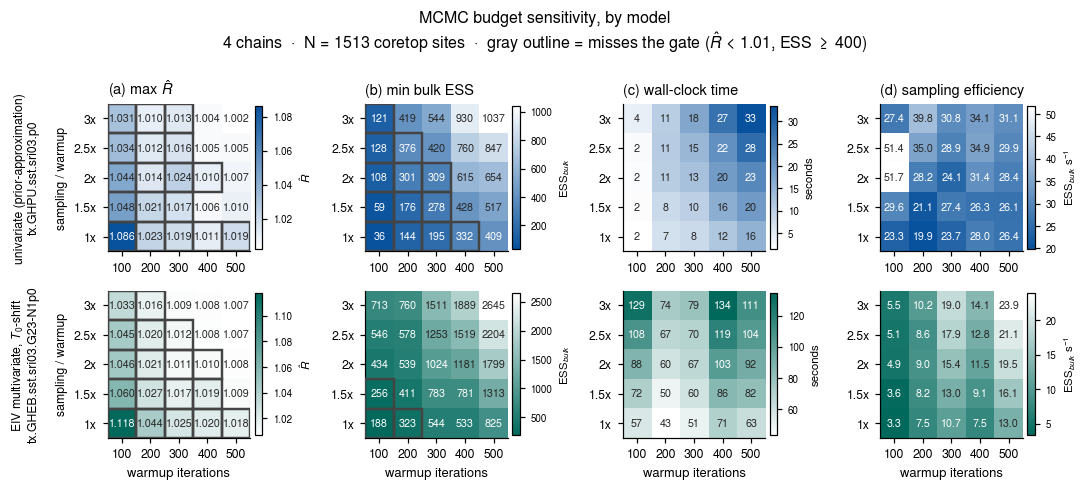

In [12]:
def _pivot(df, model_key, value):
    sub = df[(df["model"] == model_key) & (df.get("status", "ok") == "ok")]
    p = sub.pivot_table(index="multiplier", columns="iter_warmup", values=value)
    return p.reindex(index=sorted(MULTIPLIERS), columns=sorted(WARMUPS))


# One colour family per model (hue = model), and every scale oriented so that
# DARK = WORSE. That orientation has to be forced: R-hat and wall time are
# lower-is-better while ESS and efficiency are higher-is-better, so sharing one
# family across a row would otherwise make dark mean "bad" in two panels and
# "good" in the other two. Cells that miss a gate are outlined instead of being
# left to hue alone.
PANELS = [
    ("max_rhat",         "(a) max $\\hat{R}$",          "$\\hat{R}$",
     "{:.3f}", False, lambda v: v >= 1.01),
    ("min_ess_bulk",     "(b) min bulk ESS",           "ESS$_{bulk}$",
     "{:.0f}", True,  lambda v: v < 400),
    ("wall_sec",         "(c) wall-clock time",        "seconds",
     "{:.0f}", False, None),
    ("ess_bulk_per_sec", "(d) sampling efficiency",    "ESS$_{bulk}$ s$^{-1}$",
     "{:.1f}", True,  None),
]

drawn = [m for m in FIG_MODELS if not grid_df[grid_df["model"] == m[0]].empty]
fig, axs = plt.subplots(len(drawn), len(PANELS),
                        figsize=(2.5 * len(PANELS), 2.25 * len(drawn)),
                        squeeze=False)

for r, (model_key, _stan) in enumerate(drawn):
    cmap_lo = model_cmap(model_key)            # dark = high value
    cmap_hi = model_cmap(model_key, reverse=True)   # dark = low value
    for c, (metric, title, cbar, fmt, higher_is_better, fails) in enumerate(PANELS):
        ax = axs[r, c]
        P = _pivot(grid_df, model_key, metric)
        M = P.values.astype(float)
        im = ax.imshow(M, origin="lower", aspect="auto",
                       cmap=cmap_hi if higher_is_better else cmap_lo)
        ax.set_xticks(range(P.shape[1]), [str(x) for x in P.columns], fontsize=8)
        ax.set_yticks(range(P.shape[0]), [f"{y:g}x" for y in P.index], fontsize=8)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                if not np.isfinite(M[i, j]):
                    continue
                # white on the dark end, black on the light end
                frac = ((M[i, j] - np.nanmin(M)) / (np.nanmax(M) - np.nanmin(M) + 1e-12))
                dark = frac > 0.62 if not higher_is_better else frac < 0.38
                ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center",
                        fontsize=7, color="white" if dark else "0.15")
                if fails is not None and fails(M[i, j]):
                    ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           edgecolor="#444444", lw=1.6, zorder=5))
        cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(cbar, fontsize=7.5); cb.ax.tick_params(labelsize=6.5)
        if r == 0:
            ax.set_title(title, fontsize=9.5, loc="left")
        if r == len(drawn) - 1:
            ax.set_xlabel("warmup iterations", fontsize=8.5)
        if c == 0:
            _lab, _case = model_title(model_key)
            ax.set_ylabel(f"{_lab}\n{_case}\n\nsampling / warmup", fontsize=8)

_n = int(grid_df.loc[grid_df["model"] == drawn[0][0], "n_obs"].iloc[0])
fig.suptitle("MCMC budget sensitivity, by model\n"
             f"{CHAINS} chains  ·  N = {_n} coretop sites  ·  "
             "gray outline = misses the gate ($\\hat{R}$ < 1.01, ESS $\\geq$ 400)",
             fontsize=10.5)
fig.tight_layout()
fpath = os.path.join(local_github_path, "figures", "manuscript", "finalized", "supplementary")
fname = "figS19_mcmcBudget_heatmaps_bothArms.pdf"
fig.savefig(os.path.join(fpath,fname), dpi=300)

plt.show()


### Figure | Where the diagnostics flatten out

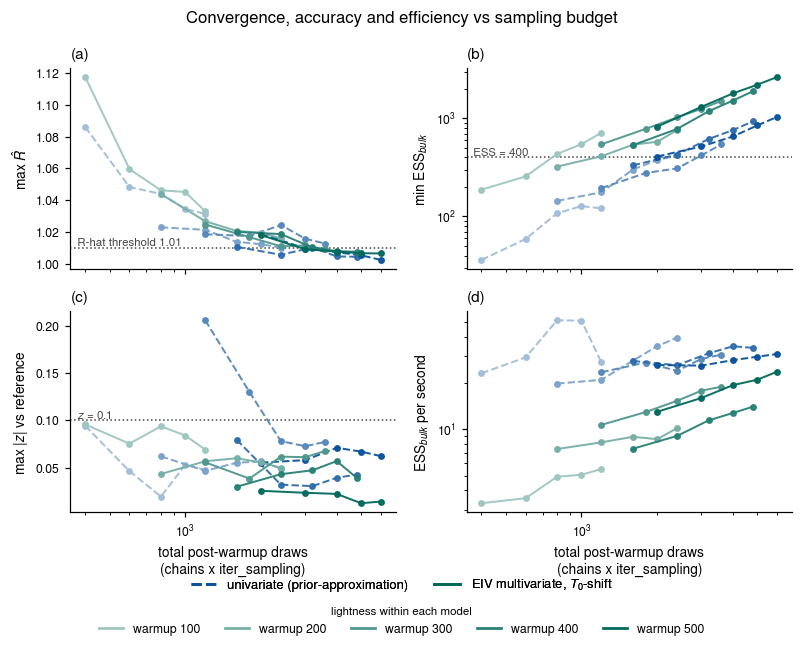

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(7.4, 5.4), sharex=True)

# Same visual grammar as the heatmaps: HUE = model, LIGHTNESS = warm-up length.
# Linestyle repeats the model so the two arms stay separable where the pale
# (short warm-up) shades of blue and teal approach each other.
MODEL_LINESTYLE = {"univ": "--", "eiv": ":", "bnd": "-"}
_shades = {k: dict(zip(sorted(WARMUPS), model_shades(k, len(WARMUPS))))
           for k, _ in FIG_MODELS}

panels = [
    ("max_rhat",         "max $\\hat{R}$",           1.01, "R-hat threshold 1.01"),
    ("min_ess_bulk",     "min ESS$_{bulk}$",         400,  "ESS = 400"),
    ("max_z_mean",       "max $|z|$ vs reference",   0.1,  "$z$ = 0.1"),
    ("ess_bulk_per_sec", "ESS$_{bulk}$ per second",  None, None),
]

# axs.ravel() walks a 2x2 row-major, so enumerate gives (a) top-left,
# (b) top-right, (c) bottom-left, (d) bottom-right -- the order the
# caption reads them in. The letter goes in the title and the metric name
# stays on the y-axis, so neither is stated twice.
for _i, (ax, (metric, ylabel, thresh, thlabel)) in enumerate(
        zip(axs.ravel(), panels)):
    for model_key, _stan in FIG_MODELS:
        sub = grid_df[(grid_df["model"] == model_key)
                      & (grid_df.get("status", "ok") == "ok")]
        if sub.empty or metric not in sub:
            continue
        for w in sorted(WARMUPS):
            s = sub[sub["iter_warmup"] == w].sort_values("iter_sampling")
            if s.empty:
                continue
            ax.plot(s["total_draws"], s[metric], MODEL_LINESTYLE[model_key],
                    marker="o", ms=3.5, color=_shades[model_key][w], lw=1.3,
                    alpha=.95)
    if thresh is not None:
        ax.axhline(thresh, color="#444444", lw=1, ls=":", zorder=0)
        ax.text(0.01, thresh, f" {thlabel}", color="#444444", fontsize=7.5,
                ha="left", va="bottom", transform=ax.get_yaxis_transform())
    ax.set_title(f"({chr(97 + _i)})", loc="left", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xscale("log")
    if metric in ("min_ess_bulk", "ess_bulk_per_sec"):
        ax.set_yscale("log")
    ax.tick_params(labelsize=8)

for ax in axs[1]:
    ax.set_xlabel("total post-warmup draws\n(chains x iter_sampling)", fontsize=9)

# Two legends, because the figure encodes two things: which model (linestyle +
# hue family) and which warm-up (lightness within that family).
h_model = [Line2D([], [], color=_shades[k][max(WARMUPS)], lw=1.8,
                  ls=MODEL_LINESTYLE[k], label=MODEL_LABEL[k])
           for k, _ in FIG_MODELS]
h_warm = [Line2D([], [], color=_shades[FIG_MODELS[-1][0]][w], lw=1.8,
                 label=f"warmup {w}") for w in sorted(WARMUPS)]
leg1 = fig.legend(handles=h_model, loc="lower center", ncol=len(h_model),
                  frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=8.5)
fig.add_artist(leg1)
fig.legend(handles=h_warm, loc="lower center", ncol=len(h_warm), frameon=False,
           bbox_to_anchor=(0.5, -0.09), fontsize=8,
           title="lightness within each model", title_fontsize=7.5)

fig.suptitle("Convergence, accuracy and efficiency vs sampling budget", fontsize=11)
fig.tight_layout()
fpath = os.path.join(local_github_path, "figures", "manuscript", "finalized", "supplementary")
fname = "figS18_mcmcBudget_convergence_curves.pdf"
fig.savefig(os.path.join(fpath,fname), dpi=300)
plt.show()


### Figure | Which parameter converges last

Reporting only the maximum R̂ hides *where* the problem is. This panel traces
R̂ per core parameter, which is what tells you whether a short warmup is
failing globally or failing on one badly identified parameter (typically the
EIV process-noise scale `sigma_proxyObs_crtp`).

saved -> /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_mcmcBudget_per_parameter_rhat.[pdf|png]


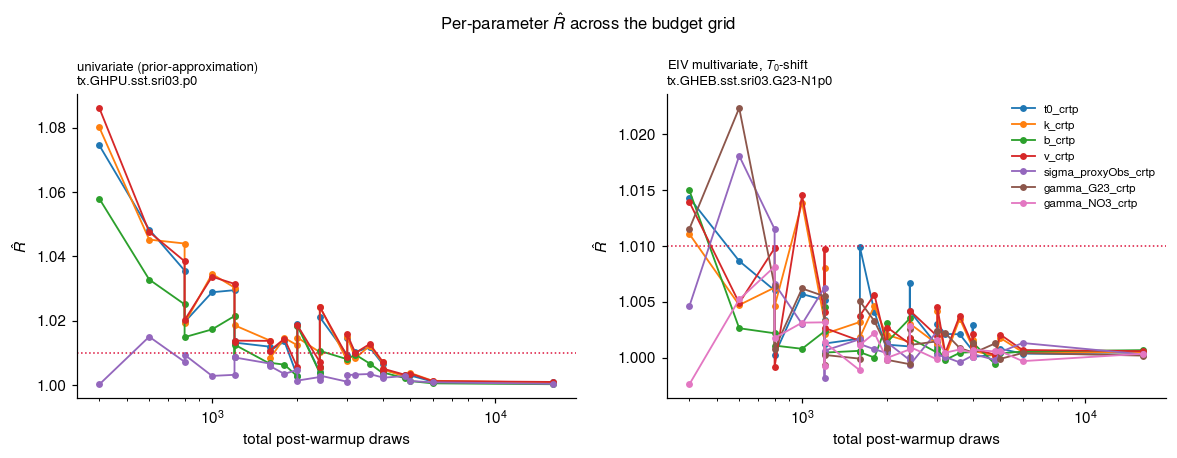

In [14]:
# Only parameters the PLOTTED arm(s) actually sample. The additive arm is still
# swept, so its beta_G23_crtp / beta_NO3_crtp rows sit in param_df even when no
# panel draws them -- left unfiltered they would consume two colour slots and
# two legend lines for series that appear nowhere on the figure.
_fig_keys = {k for k, _ in FIG_MODELS}
avail = [p for p in CORE_PARAMS
         if p in set(param_df.loc[param_df["model"].isin(_fig_keys), "param"])]
fig, axs = plt.subplots(1, len(FIG_MODELS), figsize=(5.4 * len(FIG_MODELS), 4.2),
                        squeeze=False)

pcmap = plt.get_cmap("tab10")
for ax, (model_key, stan_file) in zip(axs[0], FIG_MODELS):
    sub = param_df[param_df["model"] == model_key]
    if sub.empty:
        ax.set_visible(False)
        continue
    for i, p in enumerate(avail):
        s = (sub[sub["param"] == p]
             .assign(total=lambda d: CHAINS * d["iter_sampling"])
             .sort_values("total"))
        if s.empty:
            continue
        ax.plot(s["total"], s["rhat"], marker="o", ms=3.5, lw=1.2,
                color=pcmap(i % 10), label=p)
    ax.axhline(1.01, color="crimson", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("total post-warmup draws")
    ax.set_ylabel("$\\hat{R}$")
    _lab, _case = model_title(model_key)
    ax.set_title(f"{_lab}\n{_case}", fontsize=8.5, loc="left")

# Legend over the UNION of all panels, not just the last one. It used to be
# axs[0, -1].legend(...), which takes handles from the t0shift panel alone --
# so beta_G23_crtp and beta_NO3_crtp, which only the additive panel plots when
# that arm is shown, were drawn as unlabelled series. Colours are shared across panels (index into
# `avail`), so a reader matching the brown line against the legend would have
# read it as a gamma. Dedupe by label, keep `avail` order.
_handles = {}
for _ax in axs[0]:
    for _h, _l in zip(*_ax.get_legend_handles_labels()):
        _handles.setdefault(_l, _h)
_ordered = [(_handles[p], p) for p in avail if p in _handles]
axs[0, -1].legend([h for h, _ in _ordered], [l for _, l in _ordered],
                  fontsize=7.5, frameon=False, loc="upper right", ncol=1)
fig.suptitle("Per-parameter $\\hat{R}$ across the budget grid", fontsize=11)
fig.tight_layout()
savefig(fig, "figS_mcmcBudget_per_parameter_rhat")
plt.show()

### Recommended budget

A cell is **adequate** when all four hold simultaneously:

| criterion | threshold | rationale |
|---|---|---|
| `max_rhat` | < 1.01 | Vehtari et al. (2021) |
| `min_ess_bulk` | ≥ 400 | ≥ 100 per chain at 4 chains |
| `pct_divergent` | = 0 | any divergence biases the posterior |
| `max_z_mean` | ≤ 0.1 | posterior mean within 0.1 SD of the reference |

Among adequate cells the recommendation is the **fastest**, and the speed-up is
quoted against the 1000/1000 incumbent for the same model.

In [15]:
CRITERIA = dict(max_rhat=1.01, min_ess_bulk=400.0, pct_divergent=0.0, max_z_mean=0.1)


def recommend(df, model_key):
    sub = df[(df["model"] == model_key) & (df.get("status", "ok") == "ok")].copy()
    # The reference run is the yardstick, not a candidate.
    sub = sub[~((sub["iter_warmup"] == REF_WARMUP) & (sub["iter_sampling"] == REF_SAMPLING))]
    ok = sub[(sub["max_rhat"] < CRITERIA["max_rhat"])
             & (sub["min_ess_bulk"] >= CRITERIA["min_ess_bulk"])
             & (sub["pct_divergent"] <= CRITERIA["pct_divergent"])
             & (sub["max_z_mean"] <= CRITERIA["max_z_mean"])]
    baseline = sub[(sub["iter_warmup"] == DEFAULT_WARMUP)
                   & (sub["iter_sampling"] == DEFAULT_SAMPLING)]
    base_sec = float(baseline["wall_sec"].iloc[0]) if not baseline.empty else np.nan
    if ok.empty:
        return None, base_sec, sub
    return ok.sort_values("wall_sec").iloc[0], base_sec, sub


recommendations = {}
for model_key, stan_file in GRID_MODELS:
    best, base_sec, sub = recommend(grid_df, model_key)
    print(f"\n=== {stan_file} ===")
    if best is None:
        print("  no cell in the swept grid meets all four criteria.")
        near = sub.sort_values(["max_rhat"]).head(3)
        print("  closest cells by R-hat:")
        print(near[["iter_warmup", "iter_sampling", "max_rhat", "min_ess_bulk",
                    "pct_divergent", "max_z_mean", "wall_sec"]].to_string(index=False))
        continue
    speedup = base_sec / best["wall_sec"] if np.isfinite(base_sec) else np.nan
    recommendations[model_key] = {
        "stan_file": stan_file,
        "iter_warmup": int(best["iter_warmup"]),
        "iter_sampling": int(best["iter_sampling"]),
        "wall_sec": float(best["wall_sec"]),
        "baseline_wall_sec": base_sec,
        "speedup_vs_1000_1000": float(speedup),
        "max_rhat": float(best["max_rhat"]),
        "min_ess_bulk": float(best["min_ess_bulk"]),
        "pct_divergent": float(best["pct_divergent"]),
        "max_z_mean": float(best["max_z_mean"]),
    }
    print(f"  recommended : warmup={int(best['iter_warmup'])}, "
          f"sampling={int(best['iter_sampling'])}")
    print(f"  max R-hat   : {best['max_rhat']:.4f}   "
          f"min ESS_bulk: {best['min_ess_bulk']:.0f}")
    print(f"  divergences : {best['pct_divergent']:.2f}%   "
          f"max |z| vs reference: {best['max_z_mean']:.3f}")
    print(f"  wall time   : {best['wall_sec']:.0f} s vs {base_sec:.0f} s "
          f"at 1000/1000  ->  {speedup:.2f}x faster")

with open(RESULTS_DIR / "recommended_budget.json", "w") as fh:
    json.dump({"criteria": CRITERIA, "quick_run": QUICK,
               "recommendations": recommendations}, fh, indent=2)
print("\nwrote", RESULTS_DIR / "recommended_budget.json")


=== gen_logi_fixed_hier_crtp_univ_priorApprox ===
  recommended : warmup=400, sampling=600
  max R-hat   : 1.0057   min ESS_bulk: 428
  divergences : 0.00%   max |z| vs reference: 0.032
  wall time   : 16 s vs 31 s at 1000/1000  ->  1.92x faster

=== gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv ===
  recommended : warmup=400, sampling=800
  max R-hat   : 1.0097   min ESS_bulk: 1700
  divergences : 0.00%   max |z| vs reference: 0.049
  wall time   : 141 s vs 163 s at 1000/1000  ->  1.16x faster

=== gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift ===
  recommended : warmup=300, sampling=900
  max R-hat   : 1.0091   min ESS_bulk: 1511
  divergences : 0.00%   max |z| vs reference: 0.068
  wall time   : 79 s vs 107 s at 1000/1000  ->  1.35x faster

wrote /home/ronnie-rattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity/recommended_budget.json


---
# Part 2 | Does the crenarchaeol ring assignment change the calibration?

### The review comment

The Ring Index sums cyclopentane moieties weighted by ring number. Crenarchaeol
and its regioisomer each carry four cyclopentane rings **plus one cyclohexane
ring**, so the weight they receive is a convention:

* **3** — the count used throughout this study;
* **4** — RI₀₋₄ of Zhang et al. (2016), counting the four cyclopentane rings;
* **5** — counting the cyclohexane ring as well.

A reviewer asked whether the calibration and its temperature estimates are an
artefact of the choice. This section refits the **entire two-stage
calibration** — top layer, thermal-only coretop layer, and full EIV
multivariate coretop layer — independently under each convention, on identical
sites, and compares them on curve shape, parameter posteriors, proxy-space fit
and reconstructed-temperature skill.

In [16]:
def sd_proxyobs_for(cren_rings, n):
    '''Per-site analytical SE of the scaled RI, under the configured convention.'''
    if SD_PROXYOBS_MODE == "scaled_constant":
        val = SD_PROXYOBS_BASE
    elif SD_PROXYOBS_MODE == "ri_constant":
        val = SD_PROXYOBS_BASE * 3.0 / cren_rings
    else:
        raise ValueError(f"unknown SD_PROXYOBS_MODE {SD_PROXYOBS_MODE!r}")
    return np.full(n, val)


# Descriptive comparison of the three definitions before any model is fitted.
desc = []
for label, cfg in PROXIES.items():
    col = cfg["column"]
    for dtype in ["culture", "mesocosm", "coretop"]:
        s = gridded_combined_df.loc[gridded_combined_df["datatype"] == dtype, col].dropna()
        desc.append({"proxy": label, "column": col, "datatype": dtype,
                     "n": len(s), "mean": s.mean(), "sd": s.std(),
                     "min": s.min(), "max": s.max()})
desc_df = pd.DataFrame(desc)
desc_df.to_csv(RESULTS_DIR / "proxy_descriptive_stats.csv", index=False)

pairwise = coretop_df[PROXY_COLS].corr(method="pearson")
print("Coretop Pearson correlation between the three definitions:")
print(pairwise.round(5))
desc_df.round(4)

Coretop Pearson correlation between the three definitions:
                scaledRI_cren3  scaledRI  scaledRI_cren5
scaledRI_cren3         1.00000   0.99893         0.99708
scaledRI               0.99893   1.00000         0.99955
scaledRI_cren5         0.99708   0.99955         1.00000


,proxy,column,datatype,n,mean,sd,min,max
0,SRI03,scaledRI_cren3,culture,55,0.7010,0.1790,0.3802,0.9973
1,SRI03,scaledRI_cren3,mesocosm,8,0.7179,0.1580,0.5084,0.9368
2,SRI03,scaledRI_cren3,coretop,1513,0.5776,0.1144,0.3283,0.8695
3,SRI04,scaledRI,culture,55,0.6693,0.1851,0.3439,0.9960
4,SRI04,scaledRI,mesocosm,8,0.6988,0.1592,0.4919,0.9262
5,SRI04,scaledRI,coretop,1513,0.5634,0.1089,0.3266,0.8443
6,SRI05,scaledRI_cren5,culture,55,0.6502,0.1894,0.3150,0.9952
7,SRI05,scaledRI_cren5,mesocosm,8,0.6873,0.1601,0.4820,0.9198
8,SRI05,scaledRI_cren5,coretop,1513,0.5549,0.1058,0.3256,0.8329


saved -> /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_proxyDefinition_data_comparison.[pdf|png]


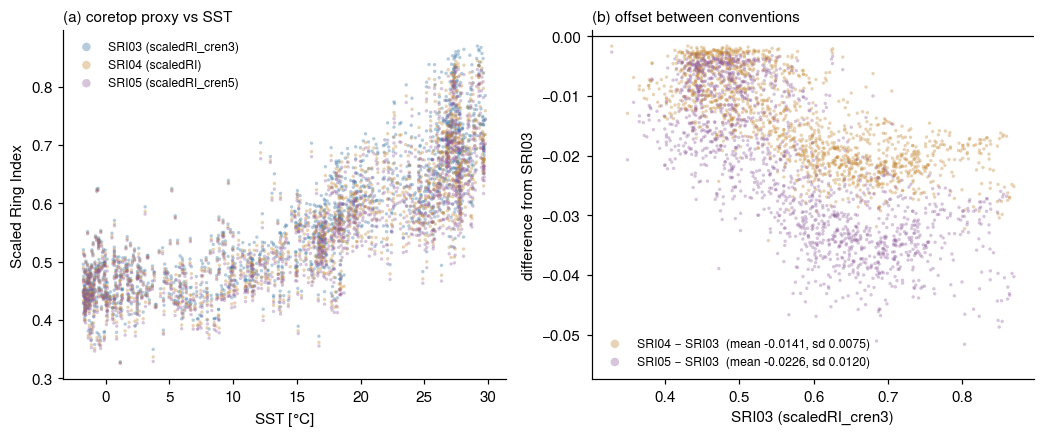

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(9.6, 4.1))
labels = list(PROXIES)

ax = axs[0]
for label in labels:
    cfg = PROXIES[label]
    ax.scatter(coretop_df["SST"], coretop_df[cfg["column"]], s=5, alpha=0.35,
               color=cfg["color"], label=f"{label} ({cfg['column']})",
               edgecolors="none")
ax.set_xlabel("SST [$\\degree$C]")
ax.set_ylabel("Scaled Ring Index")
ax.set_title("(a) coretop proxy vs SST", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, markerscale=2.5)

ax = axs[1]
ref = PROXIES[PRODUCTION_PROXY]["column"]
for label in labels:
    if label == PRODUCTION_PROXY:
        continue
    cfg = PROXIES[label]
    d = coretop_df[cfg["column"]] - coretop_df[ref]
    ax.scatter(coretop_df[ref], d, s=5, alpha=0.35, color=cfg["color"],
               edgecolors="none",
               label=f"{label} − {PRODUCTION_PROXY}  "
                     f"(mean {d.mean():+.4f}, sd {d.std():.4f})")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel(f"{PRODUCTION_PROXY} ({ref})")
ax.set_ylabel(f"difference from {PRODUCTION_PROXY}")
ax.set_title("(b) offset between conventions", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, markerscale=2.5)

fig.tight_layout()
savefig(fig, "figS_proxyDefinition_data_comparison")
plt.show()

### Refit the two-stage calibration under each convention

Three stages per proxy, in dependency order:

1. `gen_logi_fixed_culmeso` — top layer, culture + mesocosm, culturing T;
2. `gen_logi_fixed_hier_crtp_univ_priorApprox` — thermal-only coretop layer,
   which also supplies the `R2_thermal` the EIV prior is scaled by;
3. `gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv` — full model with G₂/₃ and
   NO₃.

Posteriors go to the normal forward cache via `save_posterior()`, so they are
ordinary TEXAS posteriors and can be loaded by any other notebook.
`SRI03`/stage results already produced by `SI_code2` are reused unless
`FORCE_RERUN` is set.

In [18]:
def fit_proxy_stack(label, cfg, iter_warmup=None, iter_sampling=None):
    '''Run (or reuse) the three calibration stages for one proxy definition.'''
    col = cfg["column"]
    iter_warmup   = iter_warmup   or PART2_WARMUP
    iter_sampling = iter_sampling or PART2_SAMPLING
    kw = dict(iter_warmup=iter_warmup, iter_sampling=iter_sampling,
              chains=CHAINS, seed=SEED)
    out = {}

    # ── Stage 1: culture + mesocosm ────────────────────────────────────────
    name1 = culmeso_name(col)
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["culmeso"] = load_posterior(name1)
        print(f"[{label}] stage 1 cached")
    except Exception:
        cul  = gridded_combined_df[gridded_combined_df["datatype"] == "culture"] \
                   .dropna(subset=[col, "SST"]).reset_index(drop=True)
        meso = gridded_combined_df[gridded_combined_df["datatype"] == "mesocosm"] \
                   .dropna(subset=[col, "SST"]).reset_index(drop=True)
        data = build_fwd_data(
            t_cul=cul["SST"].values,   proxy_cul=cul[col].values,
            t_meso=meso["SST"].values, proxy_meso=meso[col].values,
        )
        post, _ = get_posterior(data=data, stan_file="gen_logi_fixed_culmeso",
                                temptype="cultureT", proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["culmeso"] = post

    # ── Stage 2: thermal-only coretop ──────────────────────────────────────
    name2 = fwd_name("univ", col)
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["univ"] = load_posterior(name2)
        print(f"[{label}] stage 2 cached")
    except Exception:
        reg = coretop_df[["SST", col]].dropna()
        data = build_fwd_data(t_crtp=reg["SST"].values,
                              proxy_crtp=reg[col].values,
                              culmeso_posterior=out["culmeso"])
        post, _ = get_posterior(data=data,
                                stan_file="gen_logi_fixed_hier_crtp_univ_priorApprox",
                                temptype=TEMPTYPE, proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["univ"] = post

    R2_thermal = float(out["univ"]["R2_full"].mean())

    # ── Stage 3: full multivariate EIV coretop ─────────────────────────────
    name3 = fwd_name("eiv", col, gdgt23ratio=True, no3_cutoff=NO3_CUTOFF)
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["eiv"] = load_posterior(name3)
        print(f"[{label}] stage 3 cached")
    except Exception:
        reg = coretop_df[["SST", col, "gdgt23ratio", "gdgt23ratio_se",
                          "no3_sf2tc_avg", "thermoNO3_se"]].dropna()
        data = build_fwd_data(
            t_crtp              = reg["SST"].values,
            proxy_crtp          = reg[col].values,
            gdgt23ratio_crtp    = reg["gdgt23ratio"].values,
            sd_gdgt23ratio_crtp = reg["gdgt23ratio_se"].values,
            no3_crtp            = reg["no3_sf2tc_avg"].values,
            sd_no3_crtp         = reg["thermoNO3_se"].values,
            sd_proxyObs         = sd_proxyobs_for(cfg["cren_rings"], len(reg)),
            R2_thermal          = R2_thermal,
            culmeso_posterior   = out["culmeso"],
            no3_cutoff          = NO3_CUTOFF,
        )
        post, _ = get_posterior(
            data=data,
            stan_file="gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv",
            temptype=TEMPTYPE, proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["eiv"] = post

    # ── Stage 4: the same coretop fit under T0-shift ──────────────────────
    # Part 2 used to stop at stage 3, so the proxy-definition conclusion rested
    # on the additive arm alone. If T0-shift is the production model for the
    # revision, that is a gap: the two parameterisations put the predictors in
    # different places, and nothing guarantees a convention effect measured
    # under one carries to the other.
    #
    # Identical data dict to stage 3 -- same rows, same R2_thermal, same
    # sd_proxyObs -- so anything that differs between out["eiv"] and out["bnd"]
    # is the model and nothing else.
    name4 = fwd_name("bnd", col, gdgt23ratio=True, no3_cutoff=NO3_CUTOFF)
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["bnd"] = load_posterior(name4)
        print(f"[{label}] stage 4 (T0-shift) cached")
    except Exception:
        reg = coretop_df[["SST", col, "gdgt23ratio", "gdgt23ratio_se",
                          "no3_sf2tc_avg", "thermoNO3_se"]].dropna()
        data = build_fwd_data(
            t_crtp              = reg["SST"].values,
            proxy_crtp          = reg[col].values,
            gdgt23ratio_crtp    = reg["gdgt23ratio"].values,
            sd_gdgt23ratio_crtp = reg["gdgt23ratio_se"].values,
            no3_crtp            = reg["no3_sf2tc_avg"].values,
            sd_no3_crtp         = reg["thermoNO3_se"].values,
            sd_proxyObs         = sd_proxyobs_for(cfg["cren_rings"], len(reg)),
            R2_thermal          = R2_thermal,
            culmeso_posterior   = out["culmeso"],
            no3_cutoff          = NO3_CUTOFF,
        )
        post, _ = get_posterior(
            data=data,
            stan_file="gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift",
            temptype=TEMPTYPE, proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["bnd"] = post

    out["R2_thermal"] = R2_thermal
    out["n_crtp"] = int(out["eiv"].attrs.get("no3_crtp_len", len(coretop_df)))
    return out


posteriors = {}
for label, cfg in PROXIES.items():
    print(f"\n{'=' * 62}\n {label}  ({cfg['column']}, crenarchaeol = "
          f"{cfg['cren_rings']} rings)\n{'=' * 62}")
    posteriors[label] = fit_proxy_stack(label, cfg)

# All three conventions must be fitted to the *same* sites, or any difference
# could be a sampling artefact rather than a convention effect.
ns = {k: v["n_crtp"] for k, v in posteriors.items()}
print("\ncoretop N per proxy:", ns)
assert len(set(ns.values())) == 1, f"proxies fitted on different site counts: {ns}"


 SRI03  (scaledRI_cren3, crenarchaeol = 3 rings)
[SRI03] stage 1 cached
[SRI03] stage 2 cached
[SRI03] stage 3 cached
[SRI03] stage 4 (T0-shift) cached

 SRI04  (scaledRI, crenarchaeol = 4 rings)
[SRI04] stage 1 cached
[SRI04] stage 2 cached
[SRI04] stage 3 cached
[SRI04] stage 4 (T0-shift) cached

 SRI05  (scaledRI_cren5, crenarchaeol = 5 rings)
[SRI05] stage 1 cached
[SRI05] stage 2 cached
[SRI05] stage 3 cached
[SRI05] stage 4 (T0-shift) cached

coretop N per proxy: {'SRI03': 1513, 'SRI04': 1513, 'SRI05': 1513}


### Parameter and goodness-of-fit comparison

In [19]:
SUMMARY_PARAMS = ["t0_crtp", "k_crtp", "b_crtp", "v_crtp",
                  "sigma_proxyObs_crtp", "beta_G23_crtp", "beta_NO3_crtp"]


def _stat(ds, name):
    if name not in ds:
        return None
    v = np.asarray(ds[name].values, dtype=float).ravel()
    return dict(mean=v.mean(), sd=v.std(ddof=1),
                q025=np.percentile(v, 2.5), q160=np.percentile(v, 16),
                q500=np.percentile(v, 50), q840=np.percentile(v, 84),
                q975=np.percentile(v, 97.5))


rows = []
for label in PROXIES:
    ds = posteriors[label]["eiv"]
    for p in SUMMARY_PARAMS:
        st = _stat(ds, p)
        if st:
            rows.append({"proxy": label, "param": p, **st})
param_compare = pd.DataFrame(rows)
param_compare.to_csv(RESULTS_DIR / "proxy_parameter_comparison.csv", index=False)

fit_rows = []
for label, cfg in PROXIES.items():
    ds = posteriors[label]["eiv"]
    fit_rows.append({
        "proxy": label,
        "column": cfg["column"],
        "cren_rings": cfg["cren_rings"],
        "n_crtp": posteriors[label]["n_crtp"],
        "R2_thermal": posteriors[label]["R2_thermal"],
        "R2_full": float(ds["R2_full"].mean()) if "R2_full" in ds else np.nan,
        "bayesR2_full": float(ds["bayesR2_full"].mean()) if "bayesR2_full" in ds else np.nan,
        "RMSE_proxy": float(ds["RMSE_full"].mean()) if "RMSE_full" in ds else np.nan,
        "max_rhat": ds.attrs.get("stan_diag_max_rhat", np.nan),
        "min_ess_bulk": ds.attrs.get("stan_diag_min_ess_bulk", np.nan),
        "pct_divergent": ds.attrs.get("stan_diag_pct_divergent", np.nan),
        "overall": ds.attrs.get("stan_diag_overall_status", ""),
    })
fit_df = pd.DataFrame(fit_rows)
fit_df.round(5)

,proxy,column,cren_rings,n_crtp,R2_thermal,R2_full,bayesR2_full,RMSE_proxy,max_rhat,min_ess_bulk,pct_divergent,overall
0,SRI03,scaledRI_cren3,3,1513,0.74561,0.80128,0.86173,0.05098,1.00993,1348.55,0.0,PASS
1,SRI04,scaledRI,4,1513,0.71841,0.78386,0.84940,0.05063,1.01188,1246.68,0.0,FAIL
2,SRI05,scaledRI_cren5,5,1513,0.69949,0.77170,0.84059,0.05052,1.00887,1177.38,0.0,PASS


In [20]:
# ── Do the proxy-definition conclusions survive the model switch? ───────────
# Part 2's tables and figures above are the ADDITIVE arm. This is the T0-shift
# counterpart of the coefficient comparison.
#
# beta and gamma are not interchangeable and are never merged into one table:
# beta is scaled-RI units per predictor unit, gamma is degC per predictor unit.
# They are reported side by side, each against its own proxy definitions.
#
# The question is narrow: does the crenarchaeol ring convention move the
# correction coefficients the same way under both parameterisations? If it
# does, the convention conclusion is a property of the data rather than of the
# model, which is what Part 2 is for.
_rows = []
for _label in PROXIES:
    for _arm, _pair in (("eiv", ("beta_G23_crtp", "beta_NO3_crtp")),
                        ("bnd", ("gamma_G23_crtp", "gamma_NO3_crtp"))):
        _ds = posteriors[_label].get(_arm)
        if _ds is None:
            continue
        for _p in _pair:
            if _p not in _ds:
                continue
            _v = np.asarray(_ds[_p]).ravel()
            _rows.append(dict(proxy=_label, arm=_arm, param=_p,
                              median=float(np.median(_v)),
                              sd=float(np.std(_v, ddof=1)),
                              q16=float(np.percentile(_v, 16)),
                              q84=float(np.percentile(_v, 84))))
param_arms_df = pd.DataFrame(_rows)
param_arms_df.to_csv(RESULTS_DIR / "proxy_parameter_comparison_by_arm.csv",
                     index=False)
display(param_arms_df.round(4))

# Relative spread across the three conventions, per arm. Same denominator
# (the SRI03 production value) so the two arms are comparable as ratios even
# though their units are not.
for _arm, _pair in (("eiv", ("beta_G23_crtp", "beta_NO3_crtp")),
                    ("bnd", ("gamma_G23_crtp", "gamma_NO3_crtp"))):
    _sub = param_arms_df[param_arms_df["arm"] == _arm]
    if _sub.empty:
        continue
    print(f"\n{_arm}:")
    for _p in _pair:
        _s = _sub[_sub["param"] == _p].set_index("proxy")["median"]
        if _s.empty or PRODUCTION_PROXY not in _s.index:
            continue
        _ref = _s[PRODUCTION_PROXY]
        _spread = (_s.max() - _s.min()) / abs(_ref) * 100
        print(f"  {_p:18s} {dict(_s.round(4))}  spread = {_spread:.1f}% of "
              f"{PRODUCTION_PROXY}")


,proxy,arm,param,median,sd,q16,q84
0,SRI03,eiv,beta_G23_crtp,-0.0057,0.0004,-0.0061,-0.0053
1,SRI03,eiv,beta_NO3_crtp,-0.0460,0.0036,-0.0497,-0.0425
2,SRI03,bnd,gamma_G23_crtp,0.6307,0.0408,0.5909,0.6731
3,SRI03,bnd,gamma_NO3_crtp,2.7852,0.2418,2.5489,3.0314
4,SRI04,eiv,beta_G23_crtp,-0.0061,0.0004,-0.0065,-0.0057
5,SRI04,eiv,beta_NO3_crtp,-0.0451,0.0037,-0.0489,-0.0414
6,SRI04,bnd,gamma_G23_crtp,0.7105,0.0453,0.6663,0.7559
7,SRI04,bnd,gamma_NO3_crtp,2.8550,0.2518,2.6037,3.1057
8,SRI05,eiv,beta_G23_crtp,-0.0064,0.0004,-0.0068,-0.0060
9,SRI05,eiv,beta_NO3_crtp,-0.0445,0.0036,-0.0481,-0.0409



eiv:
  beta_G23_crtp      {'SRI03': np.float64(-0.0057), 'SRI04': np.float64(-0.0061), 'SRI05': np.float64(-0.0064)}  spread = 12.1% of SRI03
  beta_NO3_crtp      {'SRI03': np.float64(-0.046), 'SRI04': np.float64(-0.0451), 'SRI05': np.float64(-0.0445)}  spread = 3.3% of SRI03

bnd:
  gamma_G23_crtp     {'SRI03': np.float64(0.6307), 'SRI04': np.float64(0.7105), 'SRI05': np.float64(0.7641)}  spread = 21.2% of SRI03
  gamma_NO3_crtp     {'SRI03': np.float64(2.7852), 'SRI04': np.float64(2.855), 'SRI05': np.float64(2.8911)}  spread = 3.8% of SRI03


### Figure | Calibration curves and coretop posteriors

One figure, three panels. **(a)** and **(b)** are the fitted curves for the two
calibration layers; **(c)** is the coretop EIV posterior for every parameter
that enters them, together with the full-model R². These were two separate
figures before the revision — reading them apart meant holding (b)'s curves in
mind while scanning the parameter row that explains them.


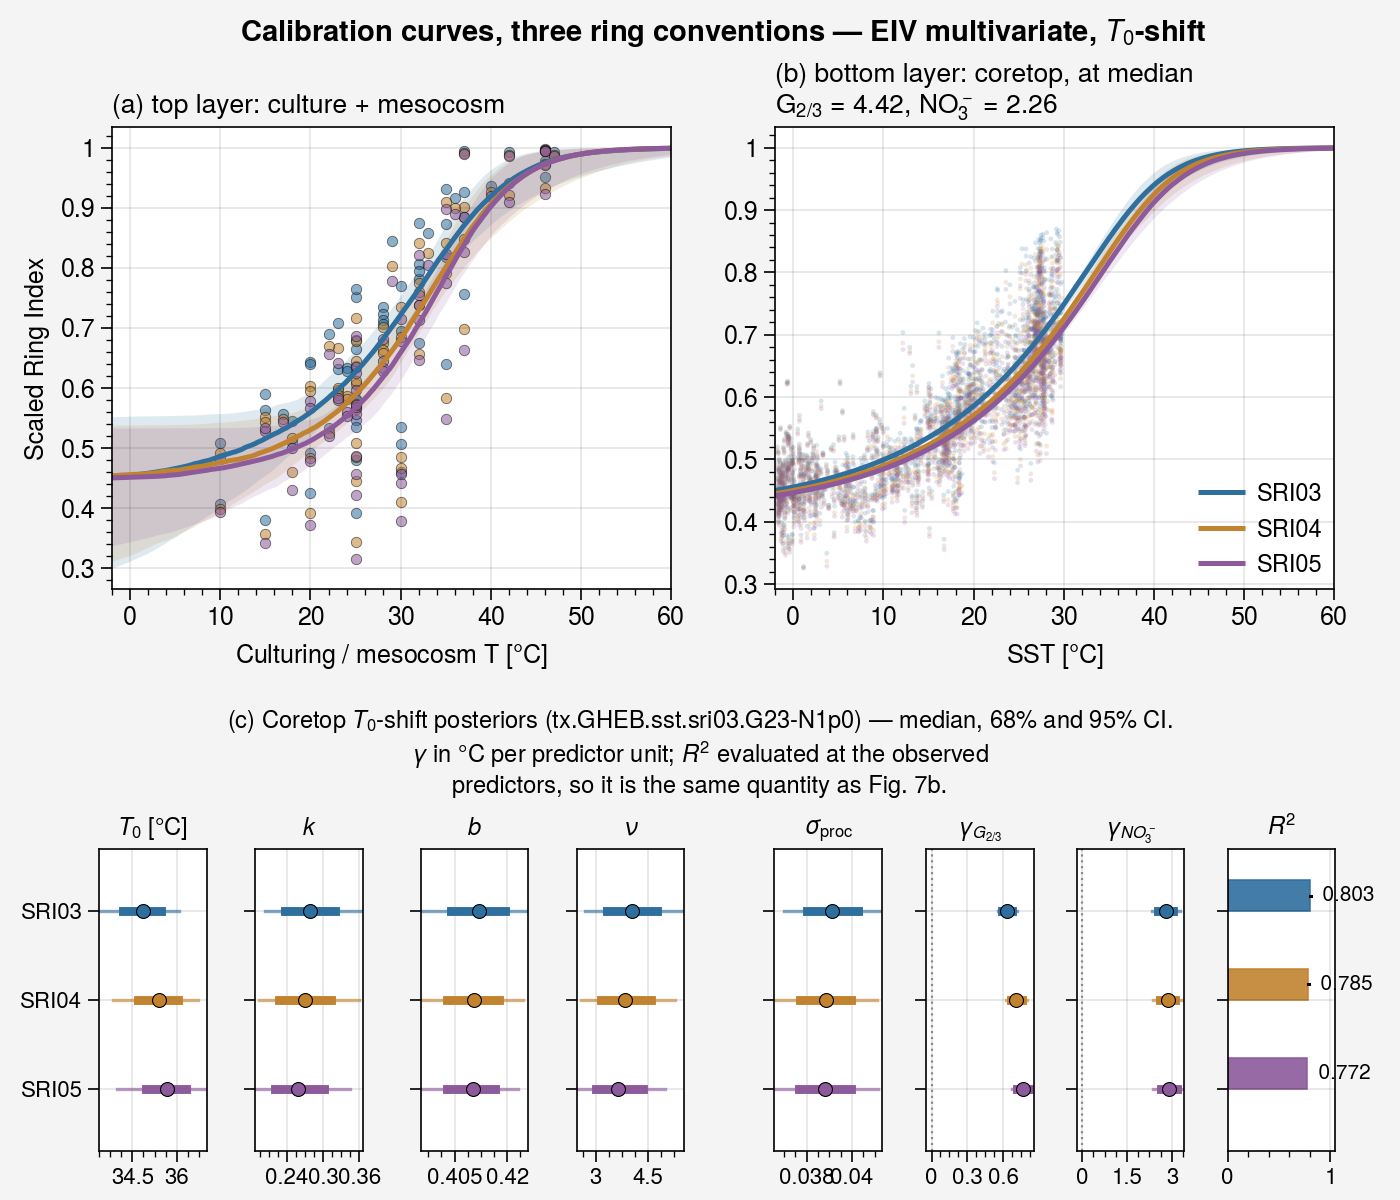

In [21]:
# ── Figure | Calibration curves and coretop posteriors, one figure ──────────
# Merged from the former figS_proxyDefinition_calibration_curves and
# figS_proxyDefinition_posterior_params. The two answer one question -- does the
# ring convention change the calibration? -- and reading them apart forced the
# reader to hold panel (b)'s curves in mind while scanning the parameter row
# that explains them. SubFigures rather than one GridSpec: the rows have very
# different panel counts (2 wide vs ncol+1 narrow) and a shared column grid
# would size the curve panels off the parameter panels.
#
# ── ARM: T0-shift, not the additive arm the tables above use ───────────────
# The manuscript reports the T0-shift calibration. Drawn from the additive fit,
# this figure showed beta coefficients -- Scaled RI units per predictor unit --
# which appear nowhere in the paper, against a bottom-layer curve the paper does
# not use. It now reads posteriors[label]["bnd"] throughout, so panel (b)'s
# curve, panel (c)'s coefficients and Table S5 of the SI are the same fit.
#
# beta and gamma are never merged, compared as numbers, or plotted on shared
# axes: beta is Scaled RI per predictor unit, gamma is degC per predictor unit.
# The additive counterpart of panel (c) is the cell above, and stays there.
#
# This cell computes its own posterior summary rather than reading
# param_compare / fit_df, which are built from the additive arm and still feed
# proxy_parameter_comparison.csv. Keeping the figure self-contained is what
# stops it drifting from its own caption the next time an arm changes.
from TEXAS.models.multivariate import generalized_logistic_fixed_upper_t0shift

ARM_FIG = "bnd"

SUMMARY_PARAMS_T0SHIFT = ["t0_crtp", "k_crtp", "b_crtp", "v_crtp",
                          "sigma_proxyObs_crtp",
                          "gamma_G23_crtp", "gamma_NO3_crtp"]

#: Panel titles carry units, because gamma's units are the whole point of the
#: reparameterisation, so they are stated once in panel (c)'s suptitle.
PARAM_LABEL = {
    "t0_crtp":             "$T_0$ [$\\degree$C]",
    "k_crtp":              "$k$",
    "b_crtp":              "$b$",
    "v_crtp":              "$\\nu$",
    "sigma_proxyObs_crtp": "$\\sigma_{\\mathrm{proc}}$",
    "gamma_G23_crtp":      "$\\gamma_{G_{2/3}}$",
    "gamma_NO3_crtp":      "$\\gamma_{NO_3^-}$",
}

_rows_fig, _fit_fig = [], []
for _label, _cfg in PROXIES.items():
    _ds = posteriors[_label][ARM_FIG]
    for _p in SUMMARY_PARAMS_T0SHIFT:
        _st = _stat(_ds, _p)
        if _st:
            _rows_fig.append({"proxy": _label, "param": _p, **_st})
    # R^2 AT THE OBSERVED PREDICTORS, per draw.
    #
    # Not R2_full. Stan's generated-quantities block builds mu from
    # true_gdgt23ratio_crtp and true_no3_crtp -- the LATENT errors-in-variables
    # values -- so R2_full describes the fit after measurement error in the
    # predictors has been accounted for (0.813 for SRI03). Every R^2 in the
    # manuscript, including Fig. 7b, is instead evaluated at the OBSERVED G23
    # and nitrate, which is what a user supplies (0.803). Plotting R2_full here
    # would put a number on an SI figure that appears in no main figure.
    #
    # Computed per draw rather than once at the posterior median, so it carries
    # a credible interval -- which is what R3C2 asked for, and the reason
    # R2_full was being quoted in the first place.
    _t0 = np.asarray(_ds["t0_crtp"].values).ravel()
    _draws = np.arange(0, len(_t0), max(1, len(_t0) // 1000))
    _pars = {q: np.asarray(_ds[f"{q}_crtp"].values).ravel()
             for q in ("t0", "b", "k", "v", "gamma_G23", "gamma_NO3")}
    _y = coretop_df[_cfg["column"]].values
    _tss = np.sum((_y - _y.mean()) ** 2)
    _r2, _rmse = [], []
    for _i in _draws:
        _mu = generalized_logistic_fixed_upper_t0shift(
            coretop_df["SST"].values,
            t0=_pars["t0"][_i], b=_pars["b"][_i], k=_pars["k"][_i], v=_pars["v"][_i],
            gamma_G23=_pars["gamma_G23"][_i],
            gdgt23ratio=coretop_df["gdgt23ratio"].values,
            gamma_NO3=_pars["gamma_NO3"][_i],
            no3=coretop_df["no3_sf2tc_avg"].values, no3_cutoff=NO3_CUTOFF)
        _rss = np.sum((_y - np.asarray(_mu)) ** 2)
        _r2.append(1 - _rss / _tss)
        _rmse.append(np.sqrt(_rss / len(_y)))
    _r2, _rmse = np.array(_r2), np.array(_rmse)
    _fit_fig.append({
        "proxy":      _label,
        "column":     _cfg["column"],
        "cren_rings": _cfg["cren_rings"],
        "R2_thermal": posteriors[_label]["R2_thermal"],
        "R2_obs":     float(np.median(_r2)),
        "R2_obs_q16": float(np.percentile(_r2, 16)),
        "R2_obs_q84": float(np.percentile(_r2, 84)),
        "RMSE_obs":   float(np.median(_rmse)),
        # kept for provenance, deliberately not plotted -- see the note above
        "R2_full_latent":   float(_ds["R2_full"].mean())   if "R2_full"   in _ds else np.nan,
        "RMSE_full_latent": float(_ds["RMSE_full"].mean()) if "RMSE_full" in _ds else np.nan,
    })
param_compare_t0shift = pd.DataFrame(_rows_fig)
fit_df_t0shift        = pd.DataFrame(_fit_fig)
param_compare_t0shift.to_csv(
    RESULTS_DIR / "proxy_parameter_comparison_t0shift.csv", index=False)

XX = np.linspace(-2, 60, 200)
g23_med = float(np.nanmedian(coretop_df["gdgt23ratio"]))
no3_med = float(np.nanmedian(coretop_df["no3_sf2tc_avg"]))

present = [p for p in SUMMARY_PARAMS_T0SHIFT
           if p in set(param_compare_t0shift["param"])]
ncol = len(present)

_arm_name, _arm_case = model_title(ARM_FIG)

# ── Layout | one ultraplot mosaic in place of two matplotlib SubFigures ────
# ultraplot's Figure owns a single GridSpec and has no SubFigure equivalent, so
# the two former subfigures become the two rows of one mosaic: the top row is
# two panels each spanning half the columns, the bottom row is one narrow panel
# per parameter. hratios reproduces the former height_ratios=[4.6, 3.0], which
# is what the split was actually buying -- rows sized independently of each
# other's panel count.
#
# The column count is derived from `present`, not hardcoded: adding a parameter
# to SUMMARY_PARAMS_T0SHIFT now widens the mosaic instead of silently pushing
# the R^2 panel off the end of a fixed 8-column array.
NBOT  = ncol + 1                      # parameter panels + the R^2 panel
_lhs  = NBOT // 2
array = [[1] * _lhs + [2] * (NBOT - _lhs),
         list(range(3, 3 + NBOT))]

# share=0, deliberately: ultraplot shares y along *rows*, so share='y' would tie
# panel (a)'s culture/mesocosm axis to panel (b)'s coretop axis, which the
# subfigures kept independent. The bottom row's former sharey=True is restored
# below with an explicit ylim instead.
# hspace opens the gap that carries the (c) caption -- see the fig.text call.
fig, axs = plot.subplots(array, figsize=(7, 6), hratios=(4.6, 3.0),
                         hspace="1.3in", share=0)

# ── (a) top layer — culture + mesocosm ─────────────────────────────────────
# Shared by both arms: stage 1 has no nonthermal predictors, so there is only
# one top layer and it is not a T0-shift-versus-additive question.
ax = axs[0]
culmeso_df = (gridded_combined_df[gridded_combined_df["datatype"].isin(["culture", "mesocosm"])]
              .dropna(subset=["SST"]))
for label, cfg in PROXIES.items():
    ens = generate_ensemble_auto(post_ds=posteriors[label]["culmeso"],
                                 x_vals=XX, percentiles=[2.5, 50, 97.5])
    ax.plot(XX, ens["p50"], color=cfg["color"], lw=1.8, label=label)
    ax.fill_between(XX, ens["p2.5"], ens["p97.5"], color=cfg["color"], alpha=0.15,
                    lw=0)
    ax.scatter(culmeso_df["SST"], culmeso_df[cfg["column"]], s=14,
               color=cfg["color"], alpha=0.55, edgecolors="k", linewidths=0.3)
ax.format(xlabel="Culturing / mesocosm T [$\\degree$C]",
          ylabel="Scaled Ring Index",
          title="(a) top layer: culture + mesocosm",
          titleloc="left", titlesize=9.5)

# ── (b) bottom layer — coretop, T0-shift EIV, at median G23 and NO3 ────────
# generate_ensemble_auto dispatches on the coefficient names present in the
# posterior (detection.py: gamma_* -> generalized_logistic_fixed_upper_t0shift),
# so passing the bnd posterior is enough -- the curve is recomputed at the
# shifted T0 rather than displaced vertically.
ax = axs[1]
for label, cfg in PROXIES.items():
    ens = generate_ensemble_auto(
        post_ds=posteriors[label][ARM_FIG], x_vals=XX,
        gdgt23ratio=np.full_like(XX, g23_med),
        no3=np.full_like(XX, no3_med),
        no3_cutoff=NO3_CUTOFF, percentiles=[2.5, 50, 97.5])
    ax.plot(XX, ens["p50"], color=cfg["color"], lw=1.8, label=label)
    ax.fill_between(XX, ens["p2.5"], ens["p97.5"], color=cfg["color"], alpha=0.15,
                    lw=0)
    # label='' keeps the scatter out of the legend: get_legend_handles_labels
    # drops falsy labels, so only the three curves are picked up below.
    ax.scatter(coretop_df["SST"], coretop_df[cfg["column"]], s=3,
               color=cfg["color"], alpha=0.18, edgecolors="none", label='')
# ylabel left blank: (a) carries it, and the two panels are one quantity.
ax.format(xlabel="SST [$\\degree$C]", ylabel="",
          title=f"(b) bottom layer: coretop, at median\n"
                f"G$_{{2/3}}$ = {g23_med:.2f}, NO$_3^-$ = {no3_med:.2f}",
          titleloc="left", titlesize=9.5)
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, fontsize=8.5, frameon=False, loc="lr", ncols=1)

# ── (c) coretop T0-shift posterior parameters + R^2 ────────────────────────
axs2 = axs[1, :]                     # the mosaic's bottom row, subplots 3..NBOT+2
labels = list(PROXIES)
ypos = {lab: i for i, lab in enumerate(labels[::-1])}

for ax, p in zip(axs2, present):
    for lab in labels:
        r = param_compare_t0shift[(param_compare_t0shift["proxy"] == lab)
                                  & (param_compare_t0shift["param"] == p)]
        if r.empty:
            continue
        r = r.iloc[0]
        y = ypos[lab]
        c = PROXIES[lab]["color"]
        ax.plot([r["q025"], r["q975"]], [y, y], color=c, lw=1.2, alpha=0.6)
        ax.plot([r["q160"], r["q840"]], [y, y], color=c, lw=3.2)
        ax.plot([r["q500"]], [y], "o", color=c, ms=5, mec="k", mew=0.4)
    # gamma is declared positive in the T0-shift model, so a zero line is the
    # boundary of the prior support and worth drawing on those two panels only.
    if p.startswith("gamma_"):
        ax.axvline(0, color="0.6", lw=0.8, ls=":", zorder=0)
    # sigma_proc spans ~0.0375-0.0405, and the default locator puts four
    # five-character labels in a panel this narrow; they overlap.
    ax.format(title=PARAM_LABEL.get(p, p.replace("_crtp", "")), titlesize=8.5,
              ticklabelsize=8, xlocator=("maxn", 3))

ax = axs2[-1]
w = 0.35
for i, lab in enumerate(labels):
    row = fit_df_t0shift[fit_df_t0shift["proxy"] == lab].iloc[0]
    y = ypos[lab] + w / 2
    # ultraplot's barh is barh(y, height, width, left) -- height is the bar
    # LENGTH and width its THICKNESS, the opposite of matplotlib's naming, so
    # matplotlib's height=w silently collided with the positional length here.
    # absolute_width keeps the thickness in data units; without it ultraplot
    # rescales it against an inferred step size and halves a scalar bar.
    ax.barh(y, row["R2_obs"], w, absolute_width=True,
            color=PROXIES[lab]["color"], alpha=0.9)
    ax.plot([row["R2_obs_q16"], row["R2_obs_q84"]], [y, y], color="k", lw=1.1)
    ax.text(row["R2_obs_q84"], y, f"  {row['R2_obs']:.3f}", va="center", fontsize=7.5)
ax.format(title="$R^2$", titlesize=8.5, ticklabelsize=8,
          xlim=(0, max(1.0, fit_df_t0shift["R2_obs"].max() * 1.3)))

# The former sharey=True on the bottom subfigure, made explicit. The margin is
# the old margins(y=0.35) written out, and it has to be applied to every panel
# rather than left to autoscaling: the R^2 bars sit at ypos + w/2, so that panel
# would otherwise settle half a bar off the parameter panels' rows.
_pad = 0.35 * (len(labels) - 1)
axs2.format(ylim=(-_pad, len(labels) - 1 + _pad),
            yticks=list(ypos.values()), yticklabels=list(ypos.keys()),
            ytickminor=False)
axs2[1:].format(yticklabels=[])

fig.format(suptitle=f"Calibration curves, three ring conventions — {_arm_name}",
           suptitlesize=10.5)

# The (c) caption was sf_bot's suptitle; one figure has only one suptitle, so it
# is drawn into the row gap instead. The anchor is a blended transform -- x in
# figure coordinates so it centres on the whole row, y in the bottom-left panel's
# axes coordinates so it rides with that row. Figure coordinates alone do not
# work here: ultraplot runs its tight layout at draw time and ignores
# free-floating figure text, so any y read off the axes beforehand is stale by
# the time the figure is saved.
_cap_tr = mpl.transforms.blended_transform_factory(fig.transFigure, axs2[0].transAxes)
fig.text(0.5, 1.17,
         f"(c) Coretop $T_0$-shift posteriors ({_arm_case}) — median, 68% and 95% CI.\n"
         "$\\gamma$ in $\\degree$C per predictor unit; $R^2$ evaluated at the observed\n"
         "predictors, so it is the same quantity as Fig. 7b.",
         transform=_cap_tr, ha="center", va="bottom", fontsize=8.5)

fpath = os.path.join(local_github_path, "figures", "manuscript", "finalized", "supplementary")
fname = "figS12_proxyDefinition_calibration_and_posteriors.pdf"
fig.savefig(os.path.join(fpath, fname), dpi=300)
plt.show()

### Reconstructed-temperature skill

Proxy-space $R^2$ is not what a reviewer cares about — the question is whether
the reconstructed temperature moves. Each coretop site is inverted through its
own calibration with the posterior-median parameters, and the residual against
observed SST is compared across conventions.

This is the deterministic point inverse (`inverse_generalized_logistic_
fixed_upper_multivariate`), not the full Bayesian marginalisation of
`predict_T_from_proxyObs`. That is deliberate: the comparison is *between*
conventions on identical sites, so the shared marginalisation machinery would
cancel, and the point inverse keeps this section to seconds rather than hours.
Absolute uncertainties quoted in the manuscript still come from the Bayesian
path.

In [22]:
def median_params(ds):
    out = {}
    for p in ["t0_crtp", "k_crtp", "b_crtp", "v_crtp",
              "beta_G23_crtp", "beta_NO3_crtp"]:
        if p in ds:
            out[p.replace("_crtp", "")] = float(np.median(np.asarray(ds[p].values)))
    return out


resid = {}
skill_rows = []
for label, cfg in PROXIES.items():
    mp = median_params(posteriors[label]["eiv"])
    t_hat = inverse_generalized_logistic_fixed_upper_multivariate(
        y=coretop_df[cfg["column"]].values,
        t0=mp["t0"], b=mp["b"], k=mp["k"], v=mp.get("v"),
        beta_G23=mp.get("beta_G23"), gdgt23ratio=coretop_df["gdgt23ratio"].values,
        beta_NO3=mp.get("beta_NO3"), no3=coretop_df["no3_sf2tc_avg"].values,
        no3_cutoff=NO3_CUTOFF,
    )
    r = np.asarray(t_hat, dtype=float) - coretop_df["SST"].values
    resid[label] = r
    ok = np.isfinite(r)
    skill_rows.append({
        "proxy": label,
        "n_invertible": int(ok.sum()),
        "n_total": len(r),
        "pct_uninvertible": 100 * (1 - ok.mean()),
        "bias_degC": float(np.nanmean(r)),
        "RMSE_degC": float(np.sqrt(np.nanmean(r[ok] ** 2))),
        "MAE_degC": float(np.nanmean(np.abs(r[ok]))),
        "p16_degC": float(np.nanpercentile(r[ok], 16)),
        "p84_degC": float(np.nanpercentile(r[ok], 84)),
    })

skill_df = pd.DataFrame(skill_rows)
skill_df.to_csv(RESULTS_DIR / "proxy_temperature_skill.csv", index=False)
skill_df.round(3)

,proxy,n_invertible,n_total,pct_uninvertible,bias_degC,RMSE_degC,MAE_degC,p16_degC,p84_degC
0,SRI03,1472,1513,2.710,-1.335,8.367,5.250,-6.025,4.781
1,SRI04,1458,1513,3.635,-1.368,8.587,5.458,-6.261,4.967
2,SRI05,1448,1513,4.296,-1.560,9.073,5.685,-6.563,4.984


In [23]:
# ── T0-shift counterpart of the temperature-residual skill table ────────────
# The cell above inverts the ADDITIVE fit, and its proxy_temperature_skill.csv
# is the additive arm's. That file is what fed the "% uninvertible" column of
# the SI's ring-convention table, which is otherwise a T0-shift table -- one
# additive column in a T0-shift table is the kind of thing a reviewer finds.
#
# The two arms invert differently, and the difference is structural rather than
# numerical. Under the additive form the predictors move the RESPONSE, so
# y_thermal = y - beta.x can leave the base-curve range (b, 1) depending on a
# site's covariates: whether a sample is invertible depends on its G23 and NO3.
# Under T0-shift the predictors move the curve's LOCATION, so
#
#     T = (t0 + gamma_G23*G23 + gamma_NO3*log10(NO3)) - ln(((1-b)/(y-b))^v - 1)/k
#
# and invertibility reduces to b < y < 1 -- a property of the observation and
# the lower asymptote alone. No covariate value can push a sample out of range.
#
# There is no T0-shift inverse in TEXAS.models (inverse_generalized_logistic_
# fixed_upper_multivariate takes beta_* only), so the shift is applied here.
# Verified by round trip against generalized_logistic_fixed_upper_t0shift:
# max |T_recovered - T_true| = 2.2e-14 degC.
from TEXAS.models.multivariate import generalized_logistic_fixed_upper_t0shift


def _invert_t0shift(y, *, t0, b, k, v, gamma_G23, gdgt23ratio,
                    gamma_NO3, no3, no3_cutoff):
    """Point inverse of the T0-shift multivariate forward model."""
    y = np.asarray(y, dtype=float)
    shift = gamma_G23 * np.asarray(gdgt23ratio, dtype=float)
    no3 = np.asarray(no3, dtype=float)
    # Gate on the OBSERVED nitrate, matching the Stan model: the NO3 term
    # applies only inside (0, no3_cutoff).
    gated = (no3 > 0) & (no3 < no3_cutoff)
    shift = shift + np.where(gated, gamma_NO3 * np.log10(np.clip(no3, 1e-12, None)), 0.0)
    with np.errstate(all="ignore"):
        core = ((1.0 - b) / (y - b)) ** v - 1.0
        t = (t0 + shift) - np.log(core) / k
    return np.where((y > b) & (y < 1.0) & np.isfinite(core) & (core > 0), t, np.nan)


resid_t0shift = {}
skill_rows_t0shift = []
for label, cfg in PROXIES.items():
    ds = posteriors[label]["bnd"]
    mp = {p.replace("_crtp", ""): float(np.median(np.asarray(ds[p].values)))
          for p in ("t0_crtp", "b_crtp", "k_crtp", "v_crtp",
                    "gamma_G23_crtp", "gamma_NO3_crtp") if p in ds}
    t_hat = _invert_t0shift(
        coretop_df[cfg["column"]].values,
        t0=mp["t0"], b=mp["b"], k=mp["k"], v=mp["v"],
        gamma_G23=mp["gamma_G23"], gdgt23ratio=coretop_df["gdgt23ratio"].values,
        gamma_NO3=mp["gamma_NO3"], no3=coretop_df["no3_sf2tc_avg"].values,
        no3_cutoff=NO3_CUTOFF,
    )
    r = np.asarray(t_hat, dtype=float) - coretop_df["SST"].values
    resid_t0shift[label] = r
    ok = np.isfinite(r)
    skill_rows_t0shift.append({
        "proxy": label,
        "n_invertible": int(ok.sum()),
        "n_total": len(r),
        "pct_uninvertible": 100 * (1 - ok.mean()),
        "bias_degC": float(np.nanmean(r)),
        "RMSE_degC": float(np.sqrt(np.nanmean(r[ok] ** 2))),
        "MAE_degC": float(np.nanmean(np.abs(r[ok]))),
        "p16_degC": float(np.nanpercentile(r[ok], 16)),
        "p84_degC": float(np.nanpercentile(r[ok], 84)),
    })

skill_df_t0shift = pd.DataFrame(skill_rows_t0shift)
skill_df_t0shift.to_csv(RESULTS_DIR / "proxy_temperature_skill_t0shift.csv",
                        index=False)

# Cross-check: invertibility under T0-shift must equal the plain count of
# observations outside (b, 1). If these ever disagree the inverse above is
# wrong, not the count.
for label, cfg in PROXIES.items():
    _b = float(np.median(np.asarray(posteriors[label]["bnd"]["b_crtp"].values)))
    _y = coretop_df[cfg["column"]].values
    _direct = 100 * np.mean((_y <= _b) | (_y >= 1.0))
    _tab = skill_df_t0shift.loc[skill_df_t0shift["proxy"] == label,
                                "pct_uninvertible"].iloc[0]
    assert abs(_direct - _tab) < 1e-9, (label, _direct, _tab)
print("invertibility cross-check passed (b < y < 1 reproduces the table)")

skill_df_t0shift.round(3)

invertibility cross-check passed (b < y < 1 reproduces the table)


,proxy,n_invertible,n_total,pct_uninvertible,bias_degC,RMSE_degC,MAE_degC,p16_degC,p84_degC
0,SRI03,1469,1513,2.908,-1.153,7.598,4.975,-6.012,4.727
1,SRI04,1459,1513,3.569,-1.275,8.465,5.334,-6.299,5.010
2,SRI05,1450,1513,4.164,-1.421,9.801,5.663,-6.442,5.251


saved -> /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_proxyDefinition_temperature_residuals.[pdf|png]


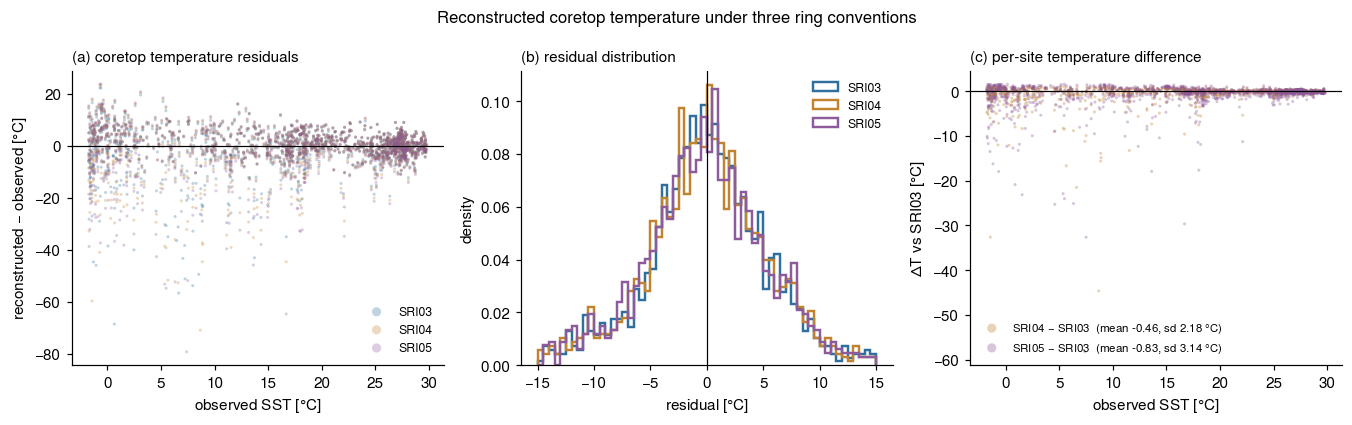

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(12.4, 3.9))

ax = axs[0]
for label, cfg in PROXIES.items():
    ax.scatter(coretop_df["SST"], resid[label], s=4, alpha=0.3,
               color=cfg["color"], edgecolors="none", label=label)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("observed SST [$\\degree$C]")
ax.set_ylabel("reconstructed − observed [$\\degree$C]")
ax.set_title("(a) coretop temperature residuals", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, markerscale=3)

ax = axs[1]
bins = np.linspace(-15, 15, 61)
for label, cfg in PROXIES.items():
    r = resid[label]
    ax.hist(r[np.isfinite(r)], bins=bins, histtype="step", lw=1.6,
            color=cfg["color"], density=True, label=label)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("residual [$\\degree$C]")
ax.set_ylabel("density")
ax.set_title("(b) residual distribution", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False)

ax = axs[2]
ref = resid[PRODUCTION_PROXY]
for label, cfg in PROXIES.items():
    if label == PRODUCTION_PROXY:
        continue
    d = resid[label] - ref
    ax.scatter(coretop_df["SST"], d, s=4, alpha=0.35, color=cfg["color"],
               edgecolors="none",
               label=f"{label} − {PRODUCTION_PROXY}  "
                     f"(mean {np.nanmean(d):+.2f}, sd {np.nanstd(d):.2f} $\\degree$C)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("observed SST [$\\degree$C]")
ax.set_ylabel(f"$\\Delta$T vs {PRODUCTION_PROXY} [$\\degree$C]")
ax.set_title("(c) per-site temperature difference", fontsize=10, loc="left")
ax.legend(fontsize=7.5, frameon=False, markerscale=3)

fig.suptitle("Reconstructed coretop temperature under three ring conventions",
             fontsize=11)
fig.tight_layout()
savefig(fig, "figS_proxyDefinition_temperature_residuals")
plt.show()

### Combined results table

In [25]:
combined = fit_df.merge(skill_df, on="proxy")
combined.to_csv(RESULTS_DIR / "proxy_definition_summary.csv", index=False)

show = ["proxy", "column", "cren_rings", "n_crtp", "R2_full", "RMSE_proxy",
        "RMSE_degC", "bias_degC", "pct_uninvertible", "max_rhat", "overall"]
print("wrote", RESULTS_DIR / "proxy_definition_summary.csv")
combined[show].round(4)

wrote /home/ronnie-rattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity/proxy_definition_summary.csv


,proxy,column,cren_rings,n_crtp,R2_full,RMSE_proxy,RMSE_degC,bias_degC,pct_uninvertible,max_rhat,overall
0,SRI03,scaledRI_cren3,3,1513,0.8013,0.0510,8.3668,-1.3345,2.7098,1.0099,PASS
1,SRI04,scaledRI,4,1513,0.7839,0.0506,8.5870,-1.3676,3.6352,1.0119,FAIL
2,SRI05,scaledRI_cren5,5,1513,0.7717,0.0505,9.0731,-1.5604,4.2961,1.0089,PASS


---
# Part 3 | How many calibration draws does a reconstruction need?

Part 1 asks how long the *forward* calibration must sample. A reconstruction has
one more knob — **M**, the number of forward-posterior parameter sets marginalised
over in the `log_sum_exp` — and that is the knob this part exists to settle.

**Why the old grid could not settle it.** It swept M ∈ {300, 500}. Those differ
by a factor 1.29 in Monte Carlo error (≈5.8% vs ≈4.5%, both ∝ 1/√M) — less than
the sampler's own seed-to-seed noise, which the same figure uses as its yardstick.
A null result was guaranteed before a chain ran. The ladder below spans M = 25 to
500, a factor 4.5 in error, so a real effect would have somewhere to show.

**Why R̂ cannot answer it either.** R̂ asks whether the chains agree about the
target they were given; M *defines* that target. A run at M = 25 converges
beautifully — to the M = 25 posterior. Convergence diagnostics are therefore
blind to M error by construction, which is why this part compares posteriors
against a long reference and against a re-seeded replicate instead of reading
R̂. The diagnostics are still recorded, to show each fit is valid.

Run by `scripts/paper/run_param_sensitivity.py part3`, which writes
`invt_budget_sites.csv` and `invt_budget_grid.csv`; this section reads them and
builds **Fig. S18**.

> The 200 sites are an equal-quota-per-bin subset spanning the proxy range, not a
> random sample. Because the invT posterior factorises across samples, N is a
> cost knob and not a difficulty knob: 200 and 1,513 sites have identical
> per-sample geometry. The quota subset deliberately over-weights the flat
> asymptotes, so its error statistics are stress-set statistics, not population
> statistics.

**The core-top ladder has one blind spot**, which is why
`scripts/paper/invt_M_paleo_check.py` exists: modern Scaled RI tops out at 0.870, while
ODP 1259 sits at 0.885–0.955 — entirely above it — and Co1010 runs down to 0.122,
below the modern floor. Above the upper asymptote the curve flattens, the
likelihood goes nearly flat in T, and the posterior turns prior-dominated. That
is the regime the manuscript actually reconstructs, and the one a core-top sweep
cannot reach. That script repeats the M ladder on four paleo records.

What the figure shows: **(b)** and **(c)** the reported intervals are ~14% too
narrow, and one number accounts for it — the mean 68% half-width is 0.857x the SD
of the reconstruction error, and that single ratio reproduces the measured
coverage at both 68% and 90%. Panel (c) shows the ratio is flat across every
cell, so this belongs to the model, not the sampler: no number of extra draws
will widen an interval the model does not believe is wide. **(d)** the M ladder
against the seed-to-seed floor.


In [26]:
# ---------------------------------------------------------------------------
# Fig. S18 | inverse budget insensitivity + predictive-interval calibration
# ---------------------------------------------------------------------------
# Delegates to scripts/paper/plot_uncertainty_calibration.py so the notebook and the
# command-line path cannot drift into producing two different figures. The
# script reads RESULTS_DIR/invt_budget_sites.csv and writes FIG_DIR.
import subprocess, sys

_sites = RESULTS_DIR / "invt_budget_sites.csv"
if not _sites.exists():
    print(f"MISSING {_sites}\n"
          "  Part 3 has not been run on this machine. Generate it with:\n"
          "      python scripts/paper/run_param_sensitivity.py part3\n"
          "  (~40 min, 8 budget cells + one seed replicate at 200 sites).")
else:
    _script = local_github_path / "scripts" / "paper" / "plot_uncertainty_calibration.py"
    _out = FIG_DIR / "figS_uncertaintyCalibration"
    _r = subprocess.run([sys.executable, str(_script), "--out", str(_out)],
                        capture_output=True, text=True)
    print(_r.stdout or _r.stderr)

    # Restate the headline numbers here so they are visible in the notebook
    # rather than only inside the figure. The reference cell is derived from the
    # grid, not hardcoded: Part 3's design has changed once already, and a
    # hardcoded (1000, 1000, 500) silently produced all-NaN when it did.
    import pandas as _pd, numpy as _np
    _d = _pd.read_csv(_sites)
    _bud = _d[["iter_warmup", "iter_sampling"]].max()
    _at = _d[(_d.iter_warmup == _bud.iter_warmup)
             & (_d.iter_sampling == _bud.iter_sampling)]
    _mref, _sref = int(_at.M.max()), int(_at.seed.min())
    _ref = _at[(_at.M == _mref) & (_at.seed == _sref)].set_index("site_row")
    _alt = _at[(_at.M == _mref) & (_at.seed != _sref)].set_index("site_row")
    if not _alt.empty:
        _seed = (_alt.p50 - _ref.p50).abs().dropna()
        print(f"\nseed-to-seed floor (M={_mref}, same cell, new seed): "
              f"median {_seed.median():.3f}, max {_seed.max():.3f} degC")
    print(f"per-site |shift in p50| against M={_mref}:")
    for _m in sorted(_at.M.unique()):
        if _m == _mref:
            continue
        _dd = (_at[(_at.M == _m) & (_at.seed == _sref)].set_index("site_row").p50
               - _ref.p50).abs().dropna()
        print(f"    M={_m:4d}  median {_dd.median():.3f}  max {_dd.max():.3f} degC")
    print("  -> the fall with M stops at the seed floor: below that, the sampler's\n"
          "     own noise, not M, is what limits a site's posterior median.")

    # ── the palaeo check: does the core-top conclusion survive extrapolation? ──
    _paleo = RESULTS_DIR / "invt_M_paleo.csv"
    if not _paleo.exists():
        print(f"\n(no {_paleo.name}; run  python scripts/paper/invt_M_paleo_check.py  "
              "to test M where the proxy leaves the modern range)")
    else:
        _p = _pd.read_csv(_paleo)
        print("\npalaeo records — per-sample |shift in p50| against M=500:")
        print(f"  {'record':20s} {'RI3 range':>14s} {'68% width':>10s} "
              f"{'M=25':>7s} {'M=300':>7s} {'% of half-width':>16s}")
        for _rec in _p.record.unique():
            _g = _p[_p.record == _rec]
            _ref = _g[_g.M == 500].set_index("sample")
            _hw = (_g[_g.M == 500].p84 - _g[_g.M == 500].p16).mean() / 2
            _d = {m: (_g[_g.M == m].set_index("sample").p50 - _ref.p50).abs().median()
                  for m in (25, 300)}
            print(f"  {_rec:20s} {_g.proxy.min():.3f}-{_g.proxy.max():.3f}  "
                  f"{2*_hw:10.2f} {_d[25]:7.3f} {_d[300]:7.3f} "
                  f"{100*_d[300]/_hw:15.1f}%")
        print("  -> ODP1259 (0.885-0.955) lies entirely above the modern coretop\n"
              "     maximum of 0.870, and its shift does NOT fall with M: at the\n"
              "     flat asymptote the estimate is prior-dominated and M is not\n"
              "     what limits it. In no record does M exceed 2.4% of the\n"
              "     reported uncertainty.")


saved /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_uncertaintyCalibration.[pdf|png]
  ratio 0.8566  residual SD 4.272 degC  mean half-width 3.659 degC
  ratio across 12 budget cells: 0.851-0.860


seed-to-seed floor (M=500, same cell, new seed): median 0.044, max 0.371 degC
per-site |shift in p50| against M=500:
    M=  25  median 0.065  max 0.422 degC
    M=  50  median 0.066  max 0.418 degC
    M= 100  median 0.049  max 0.301 degC
    M= 200  median 0.050  max 0.315 degC
    M= 300  median 0.047  max 0.259 degC
  -> the fall with M stops at the seed floor: below that, the sampler's
     own noise, not M, is what limits a site's posterior median.

palaeo records — per-sample |shift in p50| against M=500:
  record                    RI3 range  68% width    M=25   M=300  % of half-width
  ODP1259              0.885-0.955       10.74   0.131   0.130             2.4%
  Co1010               0.122-0.518       13.04   0.183   0.113             1.7%
  South Dov

### Summary for the response to reviewers

Run the cell below **after** both parts have completed; it prints the numbers
in the form they are quoted in the response letter, rather than asking anyone
to read them off the figures.

In [27]:
print("=" * 70)
print("PART 1 — sampler budget")
print("=" * 70)
if not recommendations:
    print("No recommendation: no swept cell met all four criteria.")
for k, r in recommendations.items():
    print(f"\n{r['stan_file']}")
    print(f"  recommended warmup/sampling : {r['iter_warmup']}/{r['iter_sampling']}")
    print(f"  max R-hat                   : {r['max_rhat']:.4f}  (threshold 1.01)")
    print(f"  min bulk ESS                : {r['min_ess_bulk']:.0f}  (threshold 400)")
    print(f"  divergent transitions       : {r['pct_divergent']:.2f}%")
    print(f"  posterior mean drift        : max |z| = {r['max_z_mean']:.3f} SD "
          f"vs the {REF_WARMUP}/{REF_SAMPLING} reference")
    print(f"  wall time                   : {r['wall_sec']:.0f} s vs "
          f"{r['baseline_wall_sec']:.0f} s at 1000/1000 "
          f"({r['speedup_vs_1000_1000']:.2f}x faster)")

print("\n" + "=" * 70)
print("PART 2 — crenarchaeol ring convention")
print("=" * 70)
base = combined[combined["proxy"] == PRODUCTION_PROXY].iloc[0]
for _, r in combined.iterrows():
    tag = "  (production)" if r["proxy"] == PRODUCTION_PROXY else ""
    print(f"\n{r['proxy']} — cren = {r['cren_rings']} rings{tag}")
    print(f"  R2 (proxy space) : {r['R2_full']:.4f}   "
          f"RMSE (proxy) : {r['RMSE_proxy']:.4f}")
    print(f"  RMSE (T)         : {r['RMSE_degC']:.2f} degC   "
          f"bias : {r['bias_degC']:+.2f} degC")
    if r["proxy"] != PRODUCTION_PROXY:
        d = resid[r["proxy"]] - resid[PRODUCTION_PROXY]
        print(f"  vs {PRODUCTION_PROXY}: dR2 = {r['R2_full'] - base['R2_full']:+.4f}, "
              f"dRMSE(T) = {r['RMSE_degC'] - base['RMSE_degC']:+.2f} degC, "
              f"per-site dT = {np.nanmean(d):+.2f} +/- {np.nanstd(d):.2f} degC")

print(f"\nCoretop correlation between conventions (Pearson):")
print(pairwise.round(5).to_string())
if QUICK:
    print("\n*** QUICK=True — these numbers are a smoke test, not results. ***")

PART 1 — sampler budget

gen_logi_fixed_hier_crtp_univ_priorApprox
  recommended warmup/sampling : 400/600
  max R-hat                   : 1.0057  (threshold 1.01)
  min bulk ESS                : 428  (threshold 400)
  divergent transitions       : 0.00%
  posterior mean drift        : max |z| = 0.032 SD vs the 1000/4000 reference
  wall time                   : 16 s vs 31 s at 1000/1000 (1.92x faster)

gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv
  recommended warmup/sampling : 400/800
  max R-hat                   : 1.0097  (threshold 1.01)
  min bulk ESS                : 1700  (threshold 400)
  divergent transitions       : 0.00%
  posterior mean drift        : max |z| = 0.049 SD vs the 1000/4000 reference
  wall time                   : 141 s vs 163 s at 1000/1000 (1.16x faster)

gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift
  recommended warmup/sampling : 300/900
  max R-hat                   : 1.0091  (threshold 1.01)
  min bulk ESS                : 1511  (threshold 

---
## Notes and caveats

* **R̂ is compared at a fixed chain count.** R̂ is a between-chain statistic, so
  the grid holds `chains = 4` throughout. A budget adequate at 4 chains is not
  automatically adequate at 2.
* **Wall time excludes compilation.** Stan binaries are compiled once per
  session and cached; the timings measure sampling only, which is what scales
  with the training set.
* **The recommendation is machine-relative in seconds, not in iterations.** The
  iteration counts transfer between machines; the wall times and the speed-up
  factor do not.
* **Part 1 sweeps SRI03 only.** The budget question is about data size and model
  geometry, not the proxy definition; Part 2 confirms the three conventions
  produce fits of nearly identical geometry, so the budget carries over.
* **The point inverse in Part 2 is a comparison tool.** Manuscript
  uncertainties come from `predict_T_from_proxyObs`, which marginalises over the
  whole forward posterior.